<a href="https://colab.research.google.com/github/Merenguimona/act2_Adatos/blob/main/NOTEBOOKS/EDA_DENGUE_AM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [133]:
# Instalación de librerias

install.packages(c("janitor", "skimr","lmtest", "car", "GGally"))
library(GGally)
library(tidyverse)
library(janitor)
library(skimr)
library(lmtest)
library(car)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘timeDate’, ‘urca’, ‘RcppArmadillo’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘microbenchmark’, ‘rbibutils’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘zoo’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’


Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode


The following object is masked from ‘package:purrr’:

    some




In [2]:
# Carga de base de datos
dengue_data<- read.csv("https://raw.githubusercontent.com/Merenguimona/act2_Adatos/refs/heads/main/DB/Dengue_AM.csv")

In [3]:
# Normalizar los nombres con janitor y mostrarlos
dengue_data <- clean_names(dengue_data)
names(dengue_data)

[1] "id"                         "country_or_subregion"      
 [3] "serotype"                   "year"                      
 [5] "in_out_of_subregions"       "ew"                        
 [7] "country_sp"                 "iso3166"                   
 [9] "report"                     "type"                      
[11] "x_c_tc_x100_e"              "x_sd_d_x100_e"             
[13] "x0"                         "cfr_f"                     
[15] "confirmed"                  "deaths"                    
[17] "epidemiological_week_a"     "incidence_rate_c"          
[19] "lab_confirm_incidence_rate" "number_of_records"         
[21] "population_x_1000"          "severe_dengue_d"           
[23] "total_of_dengue_cases_b"

In [4]:
# Inspección inicial
glimpse(dengue_data)

Rows: 762
Columns: 23
$ id                         <int> 6, 6, 6, 6, 6, 6, 6, 5, 2, 2, 2, 3, 2, 6, 6…
$ country_or_subregion       <chr> "Grenada", "Anguilla", "Curaçao", "Jamaica"…
$ serotype                   <chr> "  ", "DEN 1", "  ", "DEN 2", "DEN 1,2", " …
$ year                       <int> 2025, 2019, 2024, 2024, 2024, 2017, 2017, 2…
$ in_out_of_subregions       <chr> "Out", "Out", "Out", "Out", "Out", "Out", "…
$ ew                         <int> 53, 53, 53, 53, 53, 53, 53, 53, 53, 53, 53,…
$ country_sp                 <chr> "Granada", "Anguila", "Curazao", "Jamaica",…
$ iso3166                    <int> 308, 660, 531, 388, 28, 531, 388, 192, 340,…
$ report                     <chr> "01/01/2025", "01/01/2019", "01/01/2024", "…
$ type                       <chr> "Preliminar", "Preliminar", "Preliminar", "…
$ x_c_tc_x100_e              <dbl> 0.0000000, 33.3333333, 87.0229008, 2.114061…
$ x_sd_d_x100_e              <dbl> 2.30414746, 0.00000000, 0.00000000, 0.00000…
$ x0              

In [5]:
# Resumen general
summary(dengue_data)

       id        country_or_subregion      serotype        year     
 Min.   :1.000   Length   :762        Length   :762   Min.   :2014  
 1st Qu.:3.000   N.unique : 59        N.unique : 17   1st Qu.:2017  
 Median :6.000   N.blank  :  0        N.blank  :427   Median :2020  
 Mean   :4.567   Min.nchar:  4        Min.nchar:  2   Mean   :2020  
 3rd Qu.:6.000   Max.nchar: 34        Max.nchar: 11   3rd Qu.:2023  
 Max.   :7.000                                        Max.   :2026  
                                                                    
 in_out_of_subregions       ew         country_sp     iso3166     
 Length   :762        Min.   :53   Length   :762   Min.   : 28.0  
 N.unique :  2        1st Qu.:53   N.unique : 59   1st Qu.:170.0  
 N.blank  :  0        Median :53   N.blank  :  0   Median :388.0  
 Min.nchar:  2        Mean   :53   Min.nchar:  4   Mean   :408.4  
 Max.nchar:  3        3rd Qu.:53   Max.nchar: 30   3rd Qu.:652.0  
                      Max.   :53              

In [6]:
# Valores faltantes
colSums(is.na(dengue_data))

id       country_or_subregion 
                         0                          0 
                  serotype                       year 
                         0                          0 
      in_out_of_subregions                         ew 
                         0                          0 
                country_sp                    iso3166 
                         0                         91 
                    report                       type 
                         0                          0 
             x_c_tc_x100_e              x_sd_d_x100_e 
                       111                        115 
                        x0                      cfr_f 
                         0                        104 
                 confirmed                     deaths 
                        50                         43 
    epidemiological_week_a           incidence_rate_c 
                         0                          0 
lab_confirm_incidence_rate          number_of_records 
                         0                          0 
         population_x_1000            severe_dengue_d 
                         0                         54 
   total_of_dengue_cases_b 
                        36

In [8]:
#==========================
# PREPARACIÓN DEL DATASET
#==========================
# Número de registros antes de conversión
nrow(dengue_data)

[1] 762

In [10]:
# Conversión explícita a char antes de parse_number para modelo 2
# Se generaba un warning (no se observa warning en colab_SAL)
dengue_data <- dengue_data %>%
  mutate(
    across(
      c(incidence_rate_c, lab_confirm_incidence_rate),
      ~ parse_number(as.character(.))
    )
  ) %>%
  drop_na(deaths, incidence_rate_c)

In [11]:
# Número de registros después de conversión
nrow(dengue_data)

[1] 719

In [13]:
# Cuántos NA se generan
sum(is.na(dengue_data$incidence_rate_c))
mean(is.na(dengue_data$incidence_rate_c)) * 100

sum(is.na(dengue_data$lab_confirm_incidence_rate))
mean(is.na(dengue_data$lab_confirm_incidence_rate)) * 100

# Verificación
glimpse(dengue_data)

[1] 0

[1] 0

[1] 13

[1] 1.808067

Rows: 719
Columns: 23
$ id                         <int> 6, 6, 6, 6, 6, 6, 6, 5, 2, 2, 3, 2, 6, 6, 6…
$ country_or_subregion       <chr> "Grenada", "Anguilla", "Curaçao", "Jamaica"…
$ serotype                   <chr> "  ", "DEN 1", "  ", "DEN 2", "DEN 1,2", " …
$ year                       <int> 2025, 2019, 2024, 2024, 2024, 2017, 2017, 2…
$ in_out_of_subregions       <chr> "Out", "Out", "Out", "Out", "Out", "Out", "…
$ ew                         <int> 53, 53, 53, 53, 53, 53, 53, 53, 53, 53, 53,…
$ country_sp                 <chr> "Granada", "Anguila", "Curazao", "Jamaica",…
$ iso3166                    <int> 308, 660, 531, 388, 28, 531, 388, 192, 340,…
$ report                     <chr> "01/01/2025", "01/01/2019", "01/01/2024", "…
$ type                       <chr> "Preliminar", "Preliminar", "Preliminar", "…
$ x_c_tc_x100_e              <dbl> 0.0000000, 33.3333333, 87.0229008, 2.114061…
$ x_sd_d_x100_e              <dbl> 2.30414746, 0.00000000, 0.00000000, 0.00000…
$ x0              

In [14]:
#==========================
# EDA GENERAL
#==========================

# Número de países
n_distinct(dengue_data$country_or_subregion)

[1] 59

In [15]:
# Rango temporal
range(dengue_data$year)

[1] 2014 2026

In [16]:
# Resumen numérico
summary(
  dengue_data %>%
    select(deaths, incidence_rate_c)
)

     deaths        incidence_rate_c  
 Min.   :   0.00   Min.   :    0.00  
 1st Qu.:   0.00   1st Qu.:   10.81  
 Median :   0.00   Median :   83.10  
 Mean   :  90.17   Mean   :  367.22  
 3rd Qu.:  10.00   3rd Qu.:  273.30  
 Max.   :8431.00   Max.   :16160.00  

In [18]:
#===============
# DISTRIBUCIÓN Y ASIMETRÍA
#===============
# Limpieza
dengue_data <- dengue_data %>%
  filter(is.finite(deaths))

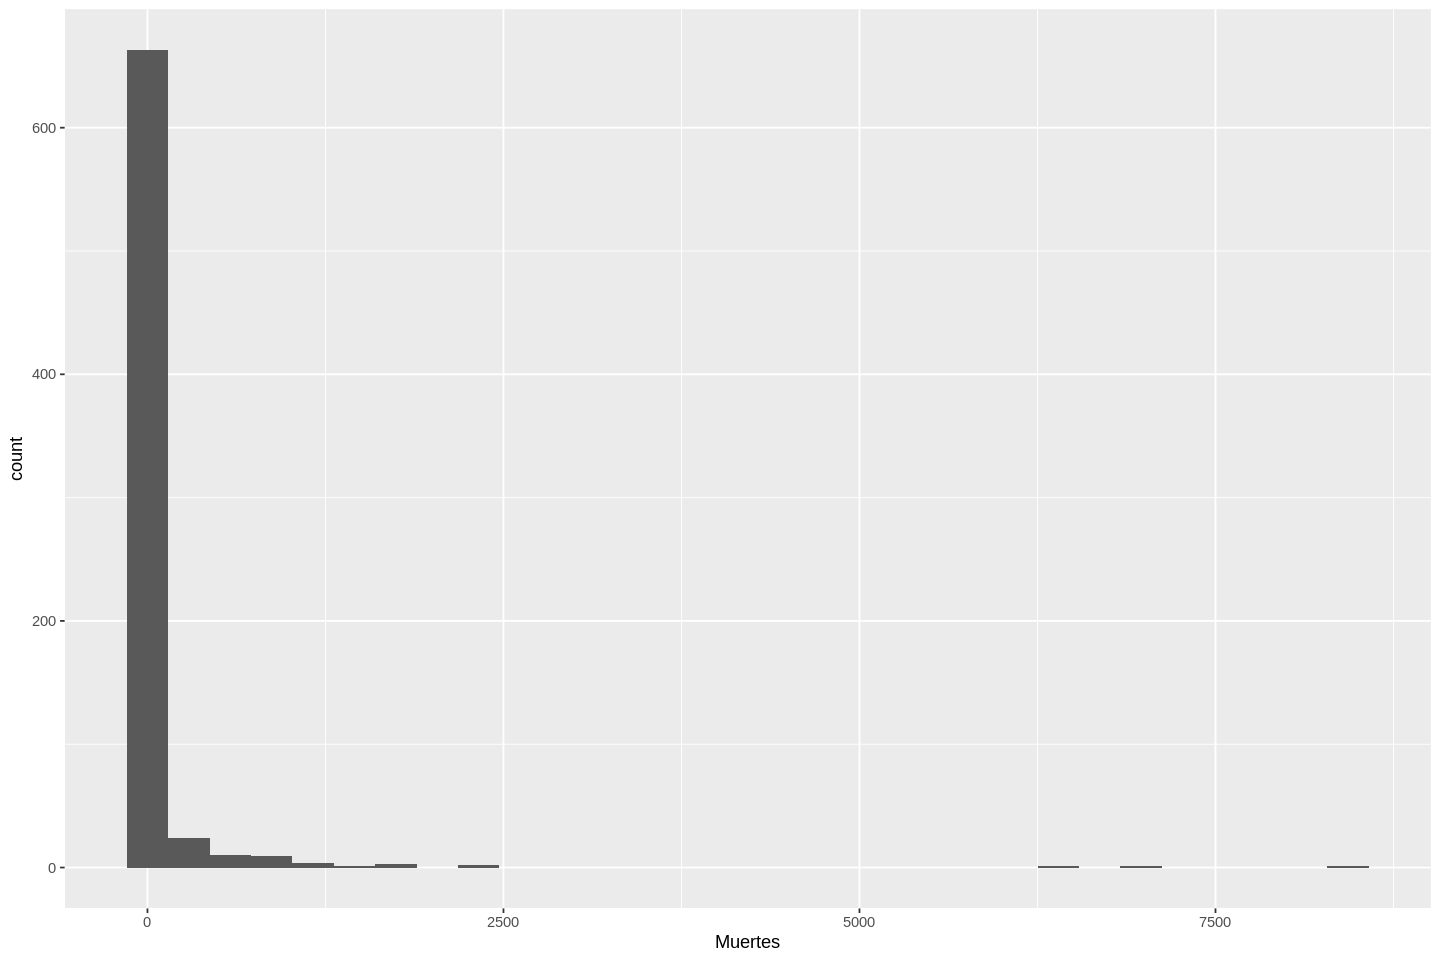

In [87]:
# Histogramas
ggplot(dengue_data, aes(x = deaths)) +
  geom_histogram(bins = 30) +
  labs(x = "Muertes")


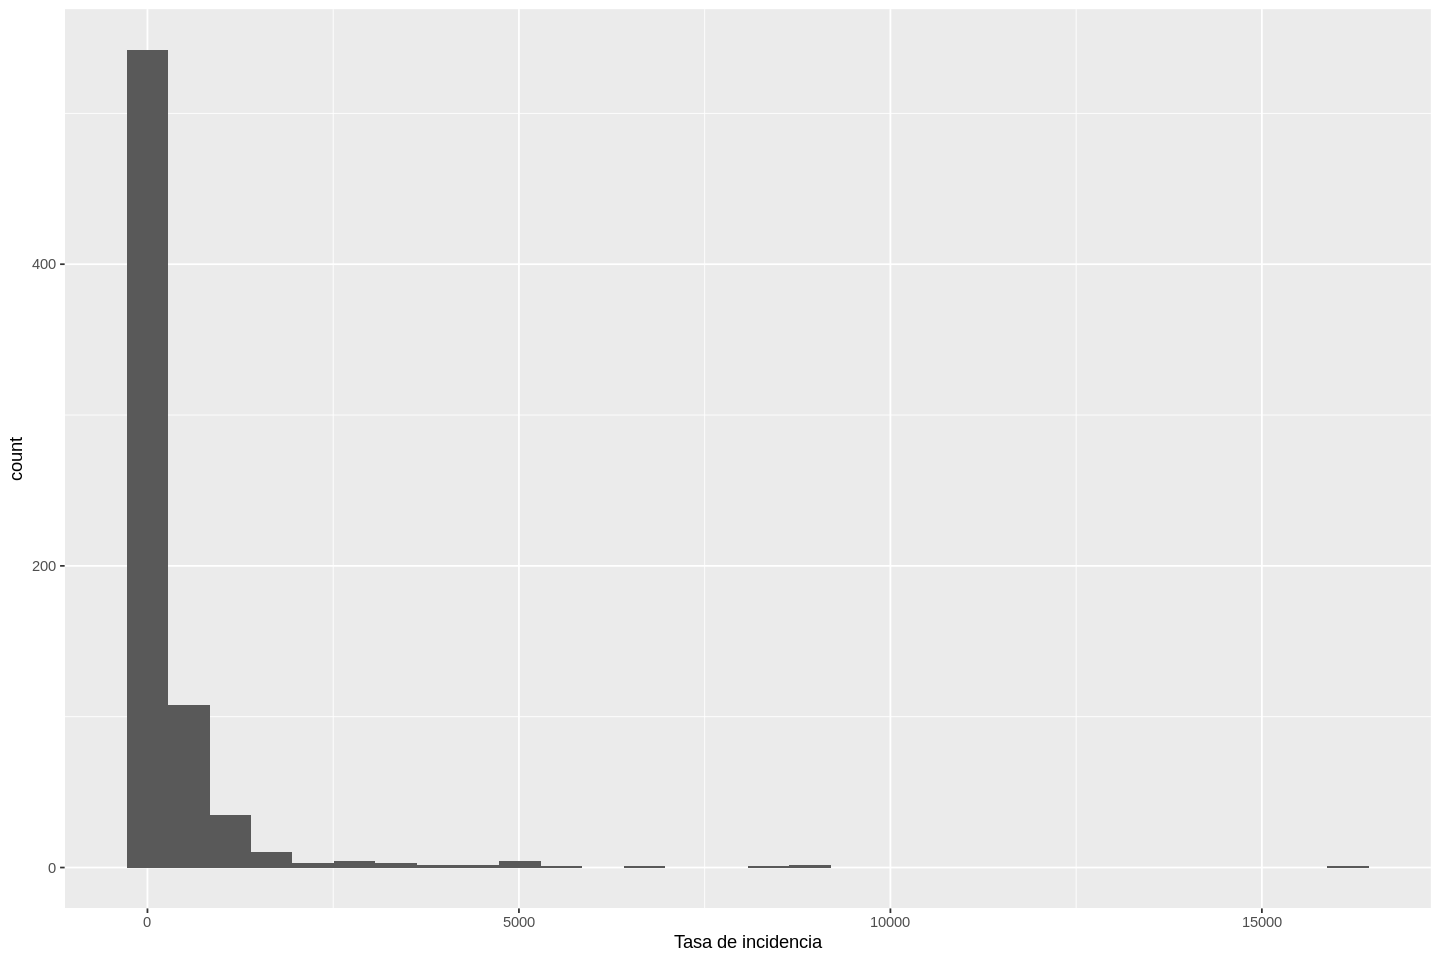

In [88]:
ggplot(dengue_data, aes(x = incidence_rate_c)) +
  geom_histogram(bins = 30) +
  labs(x = "Tasa de incidencia")

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 13 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 13 rows containing missing values or values outside the scale range
(`geom_point()`).”


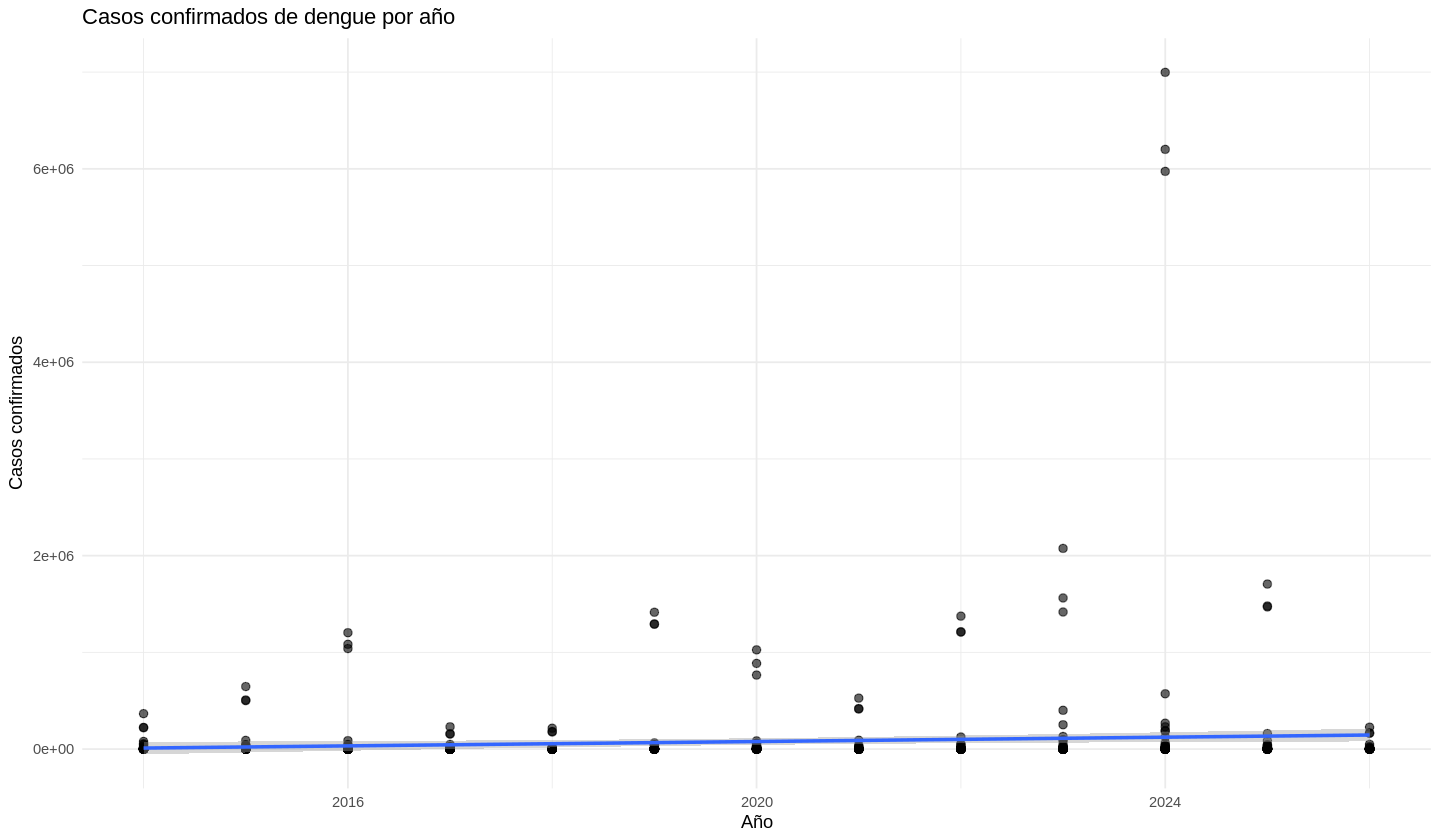

In [26]:
# Gráfico de dispersión de Casos de dengue confirmados por año, desde 2014 a 2026
options(repr.plot.width = 12, repr.plot.height = 7)

ggplot(dengue_data, aes(x = year, y = confirmed)) +
  geom_point(size = 2, alpha = 0.6) +
  geom_smooth(method = "lm", se = TRUE) +
  labs(
    title = "Casos confirmados de dengue por año",
    x = "Año",
    y = "Casos confirmados"
  ) +
  theme_minimal()

In [27]:
# Tabla de casos de Dengue confirmados en 2024 por país

casos_2024_pais <- dengue_data %>%
  filter(year == 2024) %>%
  group_by(country_sp) %>%
  summarise(
    total_confirmados = sum(confirmed, na.rm = TRUE)
  ) %>%
  arrange(desc(total_confirmados))

casos_2024_pais

country_sp,total_confirmados
<chr>,<int>
Las Américas,6997321
Cono Sur,6200875
Brasil,5973340
Subregión Andina,571938
Perú,267377
Colombia,230369
Argentina,188410
Istmo Centroamericano y México,187445
México,125160


In [28]:
tabla_id_pais <- dengue_data %>%
  select(id, country_sp) %>%
  distinct() %>%
  arrange(id)

tabla_id_pais

id,country_sp
<int>,<chr>
1,Estados Unidos de América
1,Canadá
1,América del Norte
2,Honduras
2,Panamá
2,Costa Rica
2,Belice
2,El Salvador
2,Guatemala


En teoría, en la variable "country_sp" debería de ser solamente para paises, mientras de que la variable "country_or_subregion", debe de tener ambos datos. Es por esto que se opta por crear una nueva columna para ayudar en el análisis de datos llamada `tipo_registro`.

Por otro lado para facilitar el estudio se crearán listas para agrupar los elementos que serán interesantes para el análisis.





In [29]:
# Creación de región lista consolidada

regiones_consolidadas <- c(
  "Las Américas",
  "América del Norte",
  "Istmo Centroamericano y México",
  "Subregión Andina",
  "Cono Sur",
  "Caribe Latino",
  "Caribe No Latino"
)

In [89]:
# Creación de columna nueva "tipo de registro"

dengue_data <- dengue_data %>%
  mutate(
    tipo_registro = ifelse(
      country_sp %in% regiones_consolidadas,
      "Consolidado regional",
      "País"
    )
  )

In [90]:
# Revisón de la integración de la columna
table(dengue_data$tipo_registro)


Consolidado regional                 País 
                  91                  628 

Esta columna nos sirve como un filtro para realizar  análisis de tipo regional o por paises:
```
datos_regionales <- dengue_data %>%
  filter(tipo_registro == "Consolidado regional")
```

```
datos_paises <- dengue_data %>%
  filter(tipo_registro == "País")
```
A continuación se realizará el análisis de los casos de dengue confirmados a lo largo de los años pero a nivel regional


In [33]:
# creación del filtro para casos regionales
casos_regionales_anio <- dengue_data %>%
  filter(tipo_registro == "Consolidado regional") %>%
  group_by(year, country_sp) %>%
  summarise(
    total_confirmados = sum(confirmed, na.rm = TRUE),
    .groups = "drop"
  )

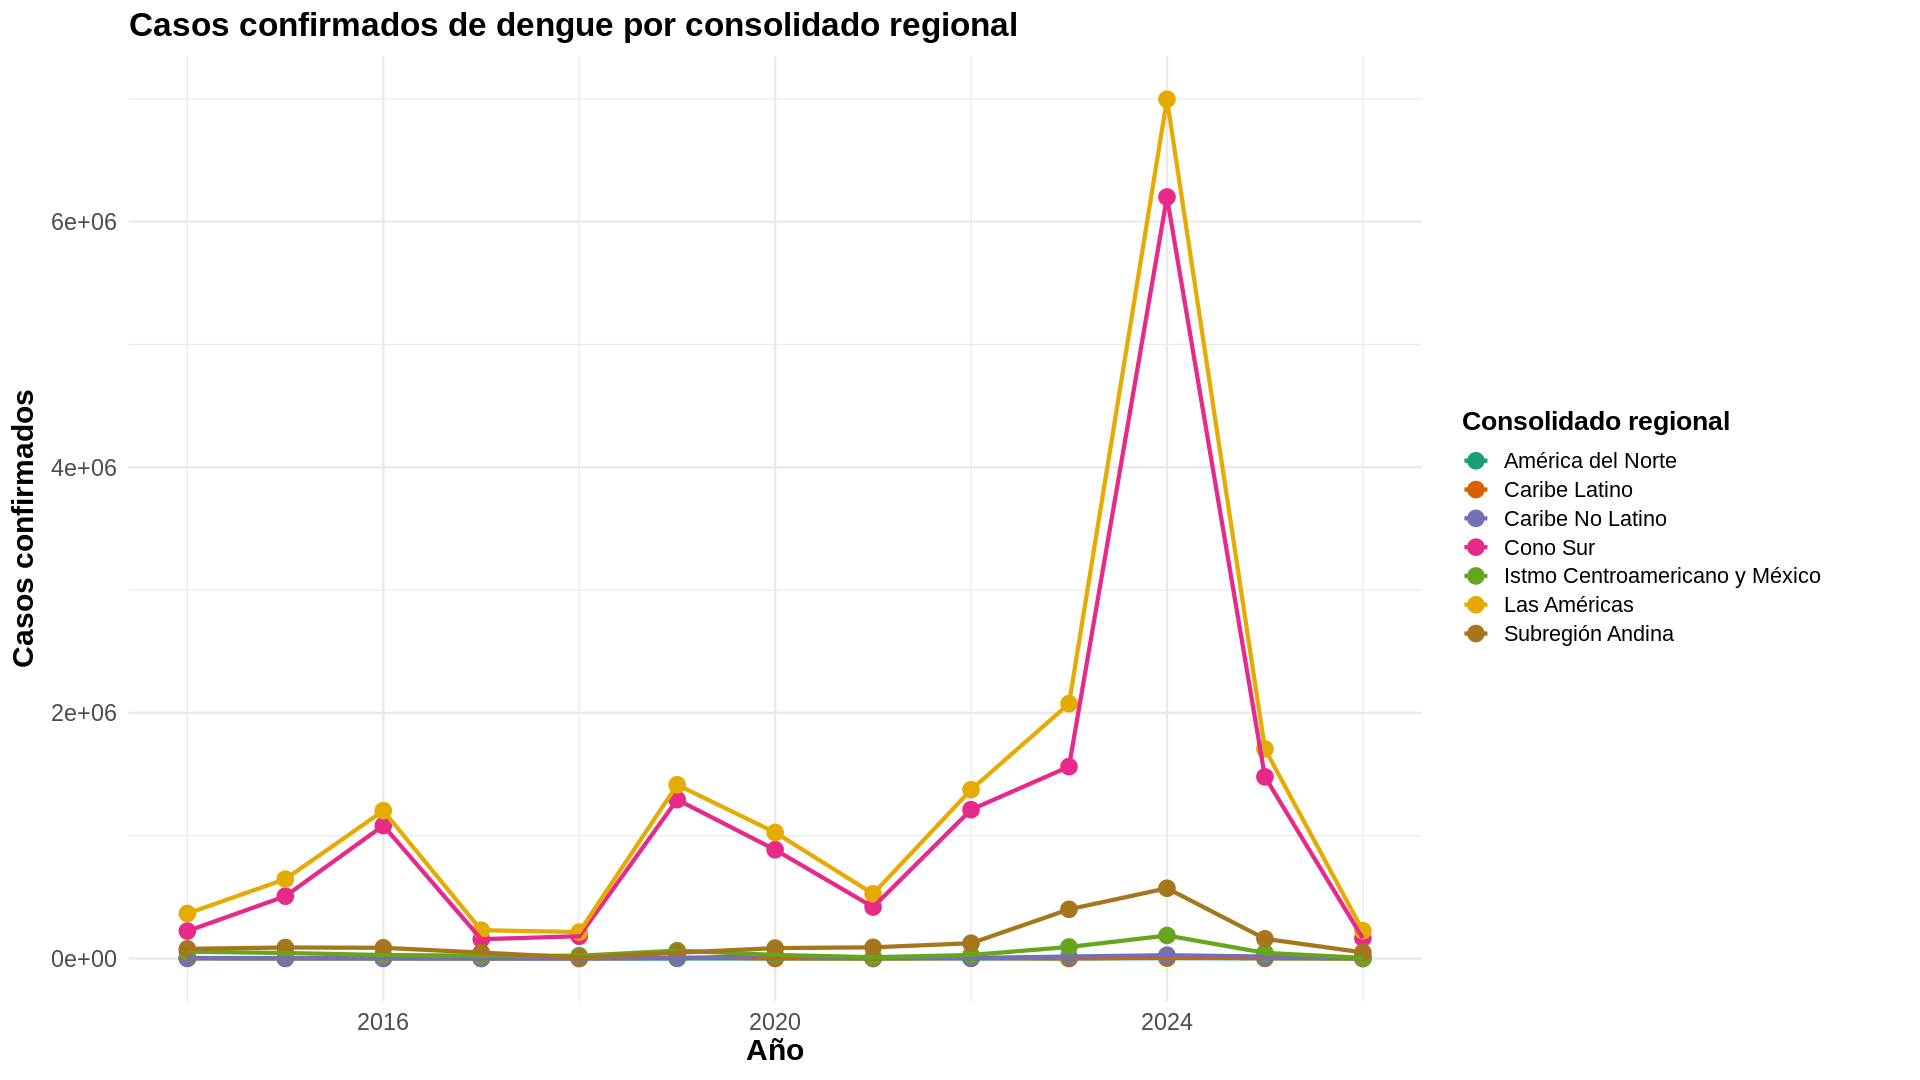

In [44]:
# Gráfico de dispersión para datos regionales y años sobre casos de dengue confirmados

options(repr.plot.width = 16, repr.plot.height = 9)

ggplot(casos_regionales_anio,
       aes(x = year, y = total_confirmados, color = country_sp)) +
  geom_point(size = 4) +
  geom_line(aes(group = country_sp), linewidth = 1.2) +
  labs(
    title = "Casos confirmados de dengue por consolidado regional",
    x = "Año",
    y = "Casos confirmados",
    color = "Consolidado regional"
  ) +
  scale_color_brewer(palette = "Dark2") +
  theme_minimal(base_size = 16) +
  theme(
    plot.title = element_text(size = 20, face = "bold"),
    axis.title = element_text(size = 18, face = "bold"),
    axis.text = element_text(size = 14),
    legend.title = element_text(size = 16, face = "bold"),
    legend.text = element_text(size = 13),
    legend.position = "right"
  )

In [91]:
# Revisión de países que se encuentran en la región de Cono Sur

paises_cono_sur <- dengue_data %>%
  filter(
    id == 4,
    tipo_registro == "País"
  ) %>%
  select(id, country_sp) %>%
  distinct() %>%
  arrange(country_sp)

paises_cono_sur

id,country_sp
<int>,<chr>
4,Argentina
4,Brasil
4,Chile
4,Paraguay
4,Uruguay


In [92]:
# Revisión de datos de casos confirmados de Dengue y países del Cono Sur
tabla_cono_sur_ancha <- dengue_data %>%
  filter(
    id == 4,
    tipo_registro == "País"
  ) %>%
  group_by(country_sp, year) %>%
  summarise(
    confirmed = sum(confirmed, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  pivot_wider(
    names_from = year,
    values_from = confirmed,
    values_fill = 0
  ) %>%
  arrange(country_sp)

tabla_cono_sur_ancha

country_sp,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
Argentina,490,1208,41211,254,1175,1720,58415,3972,841,130287,188410,8111,44
Brasil,220539,500972,1039147,156169,176814,1290861,765114,414154,1210760,1417218,5973340,1469805,164780
Chile,30,7,0,10,18,28,9,0,0,0,157,0,17
Paraguay,2601,5258,2556,616,3414,1161,62090,794,195,14936,37829,1374,197
Uruguay,0,0,0,0,0,0,4,2,20,48,1139,7,0


In [93]:
casos_cono_sur_anio <- dengue_data %>%
  filter(
    id == 4,
    tipo_registro == "País"
  ) %>%
  group_by(country_sp, year) %>%
  summarise(
    confirmed = sum(confirmed, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(country_sp, year)

casos_cono_sur_anio

country_sp,year,confirmed
<chr>,<int>,<int>
Argentina,2014,490
Argentina,2015,1208
Argentina,2016,41211
Argentina,2017,254
Argentina,2018,1175
Argentina,2019,1720
Argentina,2020,58415
Argentina,2021,3972
Argentina,2022,841


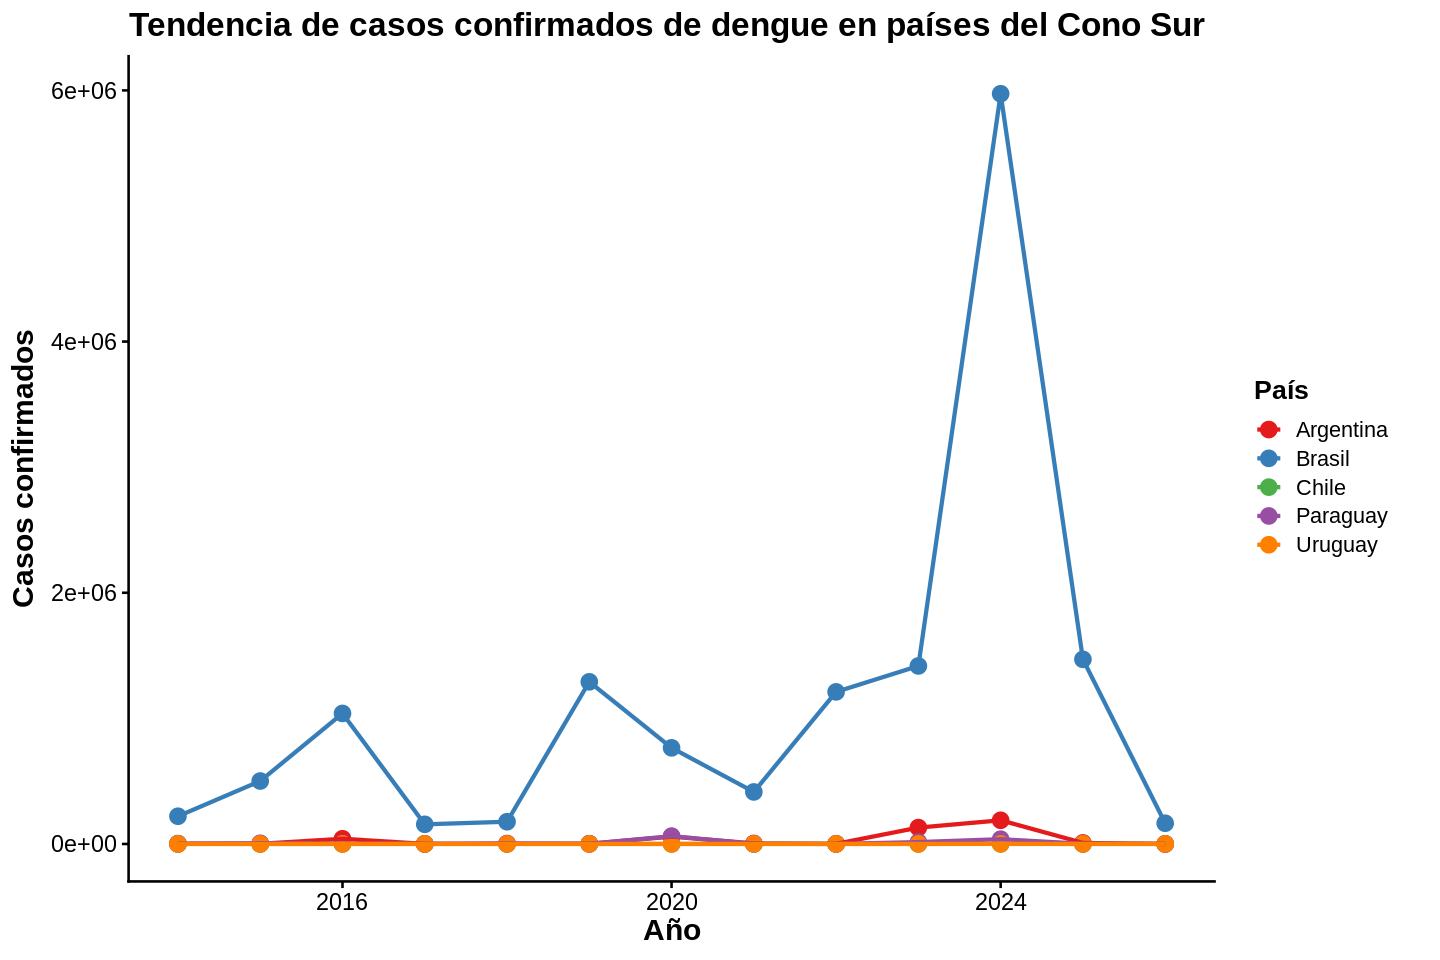

In [94]:
# Gráfico de dispersión de Cono Sur

ggplot(casos_cono_sur_anio,
       aes(x = year, y = confirmed, color = country_sp, group = country_sp)) +
  geom_point(size = 4) +
  geom_line(linewidth = 1.2) +
  labs(
    title = "Tendencia de casos confirmados de dengue en países del Cono Sur",
    x = "Año",
    y = "Casos confirmados",
    color = "País"
  ) +
  scale_color_brewer(palette = "Set1") +
  theme_classic(base_size = 16) +
  theme(
    plot.title = element_text(size = 20, face = "bold"),
    axis.title = element_text(size = 18, face = "bold"),
    axis.text = element_text(size = 14),
    legend.title = element_text(size = 16, face = "bold"),
    legend.text = element_text(size = 13)
  )

In [95]:
# Creamos un nuevo dataset con las variables de estudio seleccionadas
# Se conserva id para identificar la agrupación regional

dengue_clean <- dengue_data %>%
  select(
    id,
    country_sp,
    year,
    incidence_rate_c,
    deaths,
    confirmed,
    severe_dengue_d,
    total_of_dengue_cases_b
  )

# Clasificación de registros según nivel geográfico

regiones_consolidadas <- c(
  "Las Américas",
  "América del Norte",
  "Istmo Centroamericano y México",
  "Subregión Andina",
  "Cono Sur",
  "Caribe Latino",
  "Caribe No Latino"
)

dengue_clean <- dengue_clean %>%
  mutate(
    tipo_registro = ifelse(
      country_sp %in% regiones_consolidadas,
      "Consolidado regional",
      "País"
    )
  )

table(dengue_clean$tipo_registro)


Consolidado regional                 País 
                  91                  628 

In [96]:
#===================================================
# CREACIÓN DE BASE DE DATOS PARA ANÁLISIS REGIONALES
#===================================================

dengue_regional <- dengue_data %>%
  filter(tipo_registro == "Consolidado regional")

table(dengue_regional$country_sp)


             América del Norte                  Caribe Latino 
                            13                             13 
              Caribe No Latino                       Cono Sur 
                            13                             13 
Istmo Centroamericano y México                   Las Américas 
                            13                             13 
              Subregión Andina 
                            13 

In [97]:
#===============
# DISTRIBUCIÓN Y ASIMETRÍA
#===============
# Limpieza
dengue_data <- dengue_data %>%
  filter(is.finite(deaths))

In [98]:
glimpse(dengue_clean)

Rows: 719
Columns: 9
$ id                      <int> 6, 6, 6, 6, 6, 6, 6, 5, 2, 2, 3, 2, 6, 6, 6, 6…
$ country_sp              <chr> "Granada", "Anguila", "Curazao", "Jamaica", "A…
$ year                    <int> 2025, 2019, 2024, 2024, 2024, 2017, 2017, 2018…
$ incidence_rate_c        <dbl> 185.47, 42.86, 141.62, 71.64, 181.72, 0.00, 7.…
$ deaths                  <int> 0, 0, 0, 1, 0, 0, 6, 0, 180, 6, 14, 0, 0, 0, 0…
$ confirmed               <int> 0, 2, 228, 43, 17, 0, 0, 2128, 180, 1828, 304,…
$ severe_dengue_d         <int> 5, 0, 0, 0, 0, 0, 38, 0, 19447, 11, 31, 21, 0,…
$ total_of_dengue_cases_b <int> 217, 6, 262, 2034, 169, 0, 215, 2128, 132143, …
$ tipo_registro           <chr> "País", "País", "País", "País", "País", "País"…


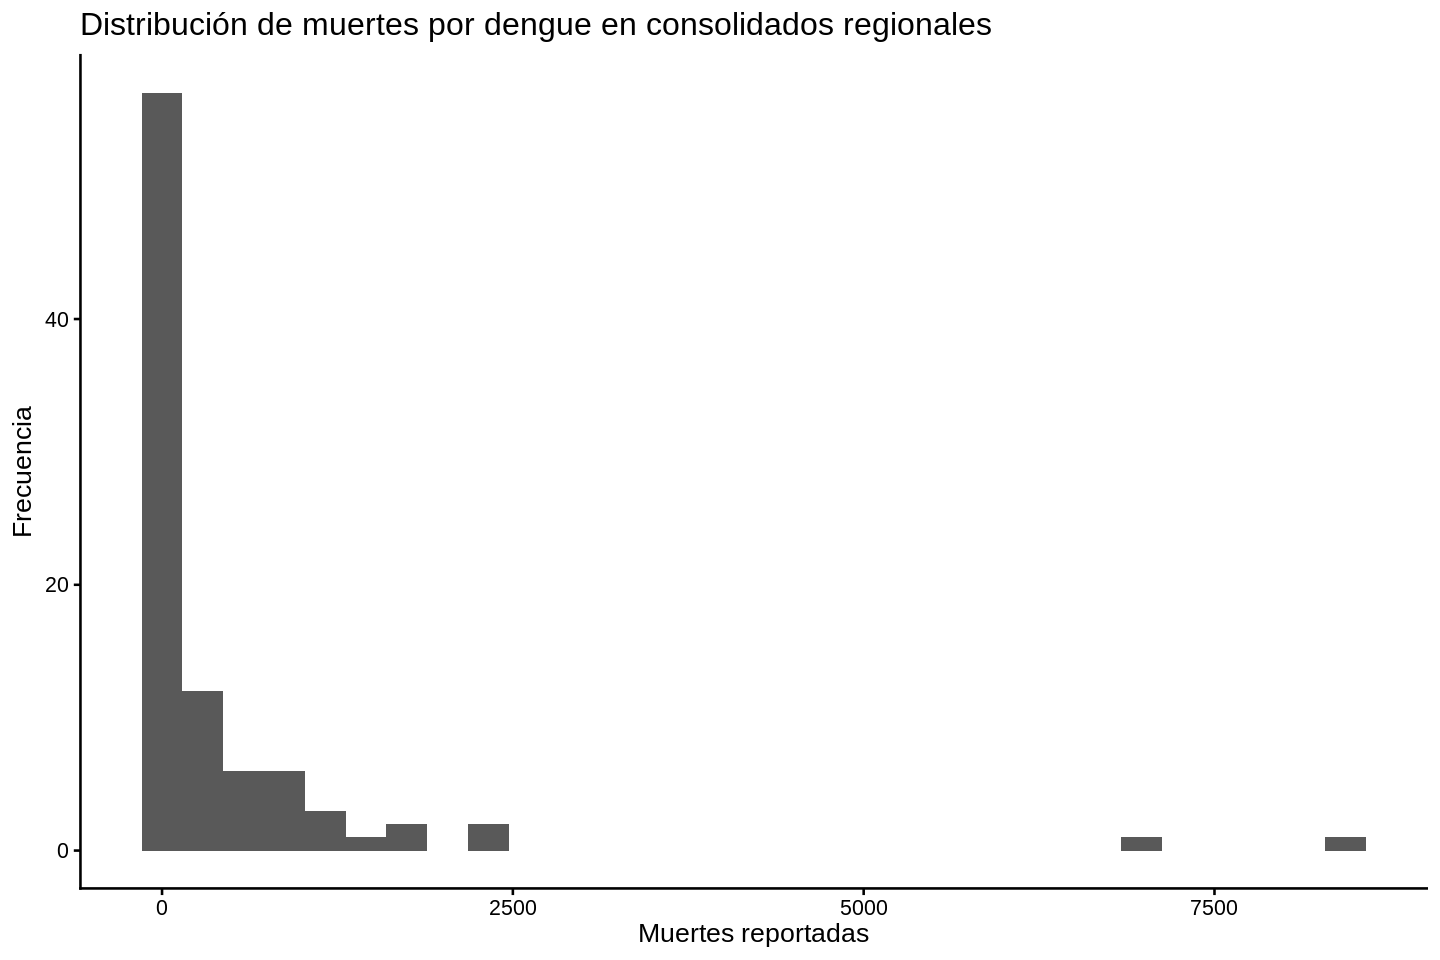

In [99]:
# HISTOGRAMAS A NIVEL REGIONAL SOBRE MUERTES REPORTADAS POR DENGUE

ggplot(dengue_regional, aes(x = deaths)) +
  geom_histogram(bins = 30) +
  labs(
    title = "Distribución de muertes por dengue en consolidados regionales",
    x = "Muertes reportadas",
    y = "Frecuencia"
  ) +
  theme_classic(base_size = 16)

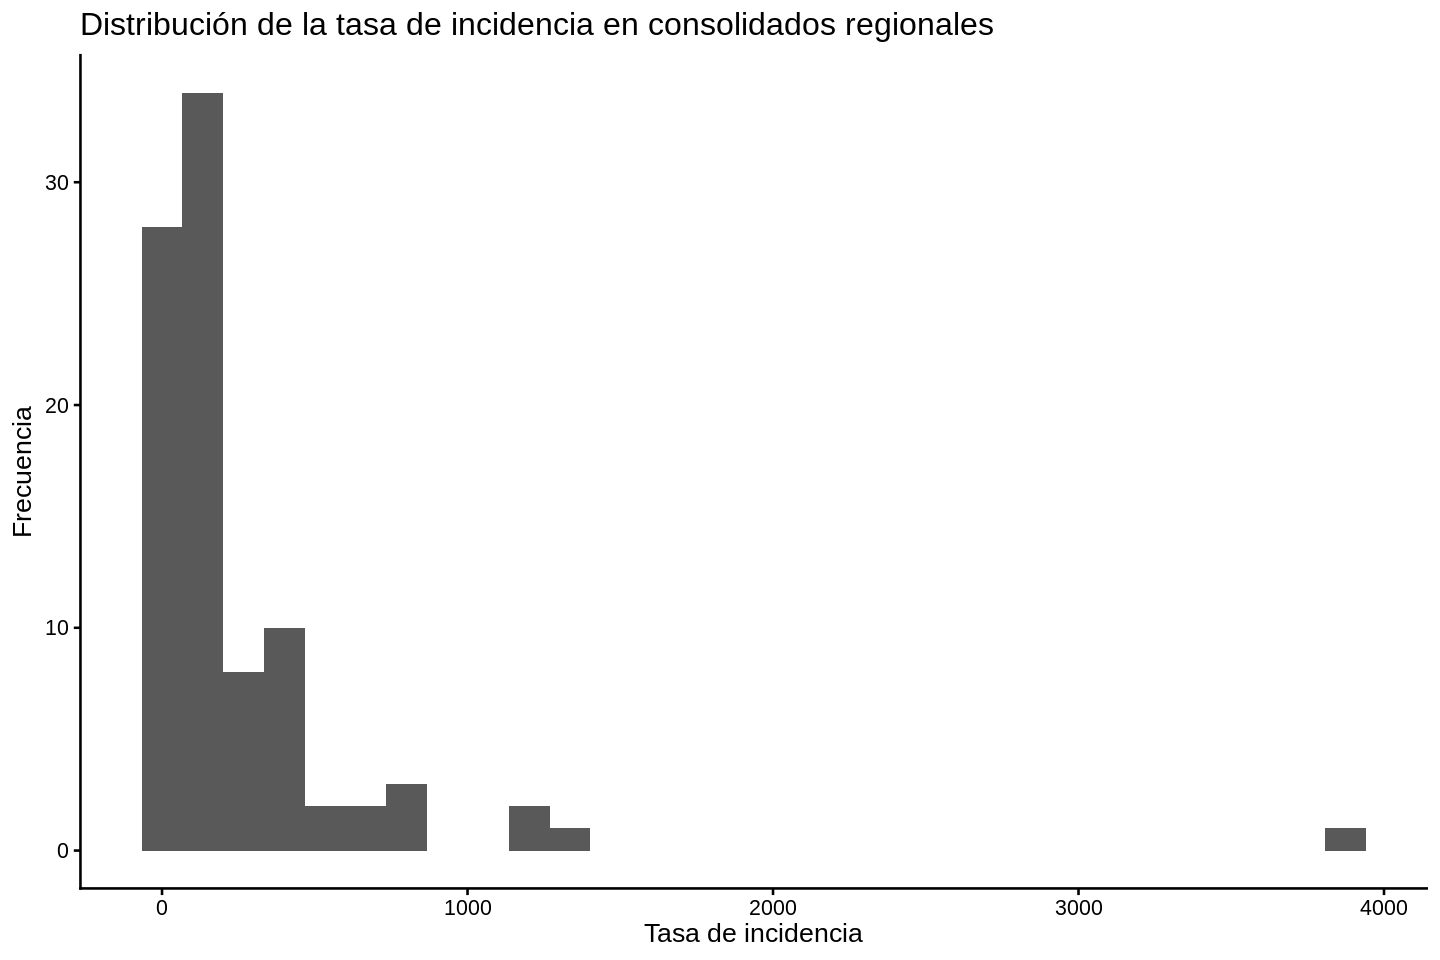

In [100]:
# INCIDENCIA A NIVEL REGIONAL
ggplot(dengue_regional, aes(x = incidence_rate_c)) +
  geom_histogram(bins = 30) +
  labs(
    title = "Distribución de la tasa de incidencia en consolidados regionales",
    x = "Tasa de incidencia",
    y = "Frecuencia"
  ) +
  theme_classic(base_size = 16)

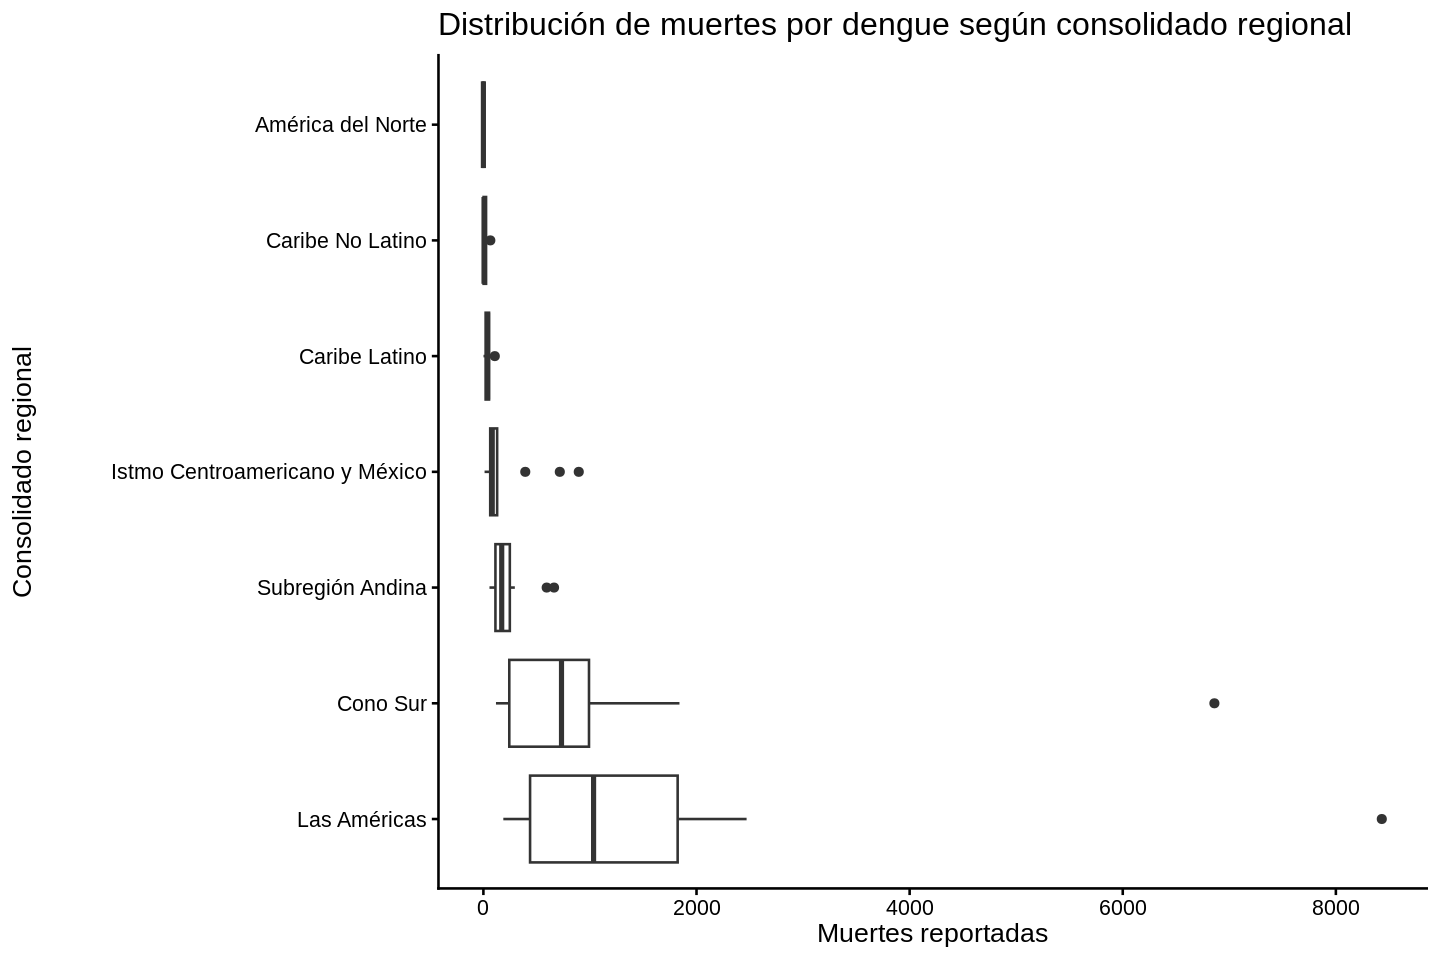

In [101]:
#BOXPLOT DE LA DISTIBUCIÓN DE MUERTES POR REGIÓN

ggplot(dengue_regional,
       aes(x = fct_reorder(country_sp, deaths, .fun = median, na.rm = TRUE, .desc = TRUE),
           y = deaths)) +
  geom_boxplot() +
  coord_flip() +
  labs(
    title = "Distribución de muertes por dengue según consolidado regional",
    x = "Consolidado regional",
    y = "Muertes reportadas"
  ) +
  theme_classic(base_size = 16)

La región del Cono Sur, es la que posee mayor distribución de muertes en todo el continente Americano.

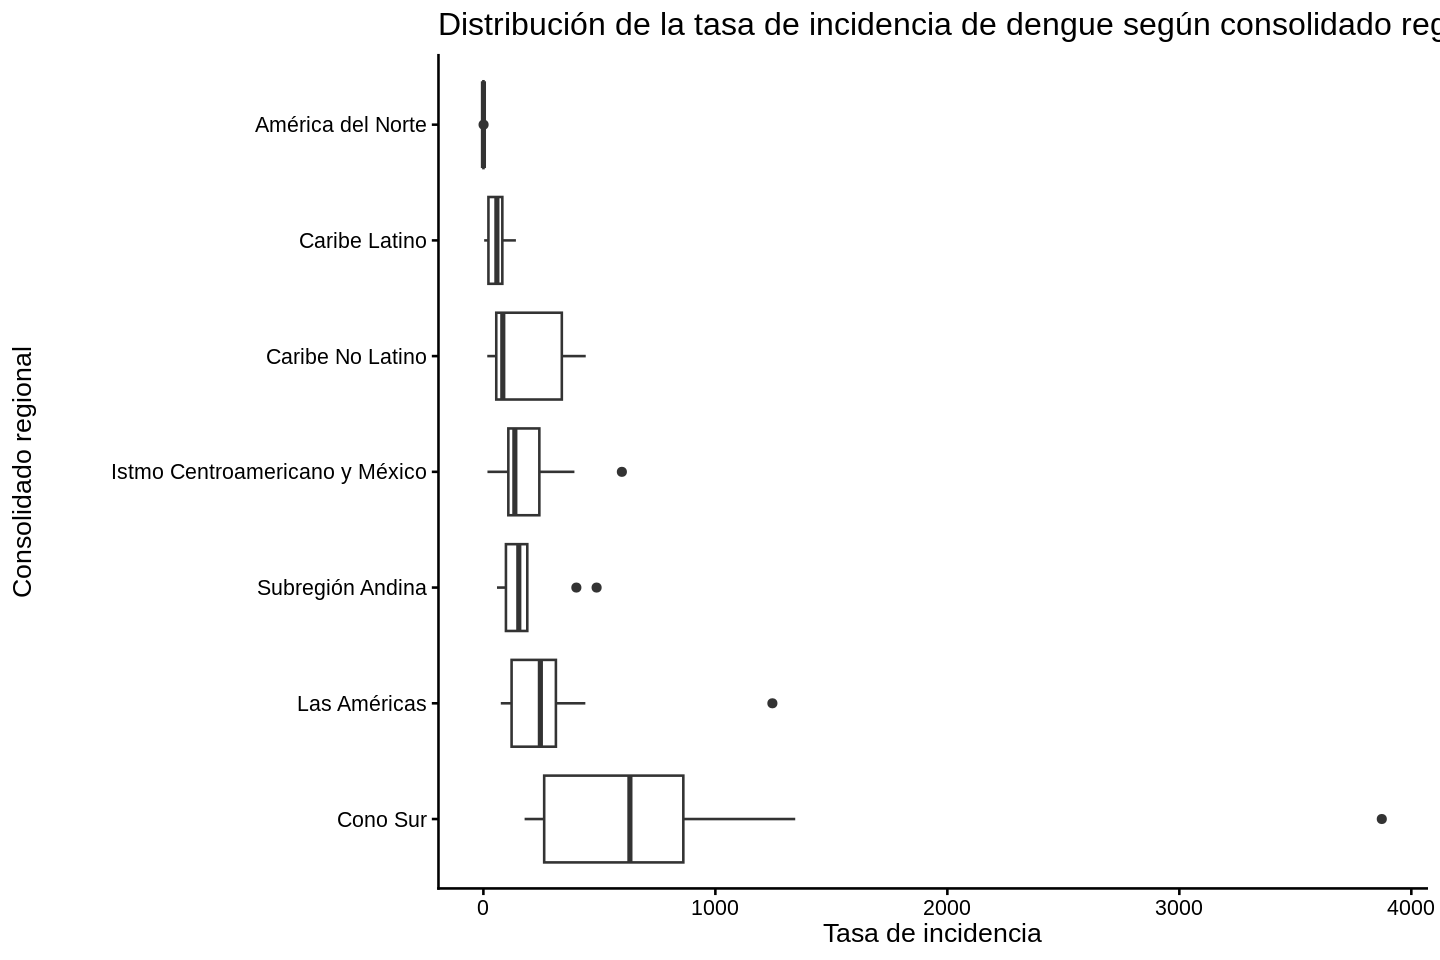

In [102]:
# BOXPLOT DE LA DISTRIBUCIÓN DE TASA DE INCIDENCIA DE DENGUE SEGÚN CONSOLIDADO REGIONAL
ggplot(dengue_regional,
       aes(x = fct_reorder(country_sp, incidence_rate_c, .fun = median, na.rm = TRUE, .desc = TRUE),
           y = incidence_rate_c)) +
  geom_boxplot() +
  coord_flip() +
  labs(
    title = "Distribución de la tasa de incidencia de dengue según consolidado regional",
    x = "Consolidado regional",
    y = "Tasa de incidencia"
  ) +
  theme_classic(base_size = 16)

La tasa de incidencia del Cono Sur es la más alta de tod el continente Americano.

Los boxplots de muertes reportadas y tasa de incidencia se presentan con escalas independientes, debido a que corresponden a variables de distinta naturaleza y magnitud. Por ello, cada gráfico debe interpretarse por separado, considerando la distribución interna de cada indicador según consolidado regional.

## __RELACIÓN VISUAL__

Ignoring unknown labels:
• colour : "Consolidado regional"
`geom_smooth()` using formula = 'y ~ x'


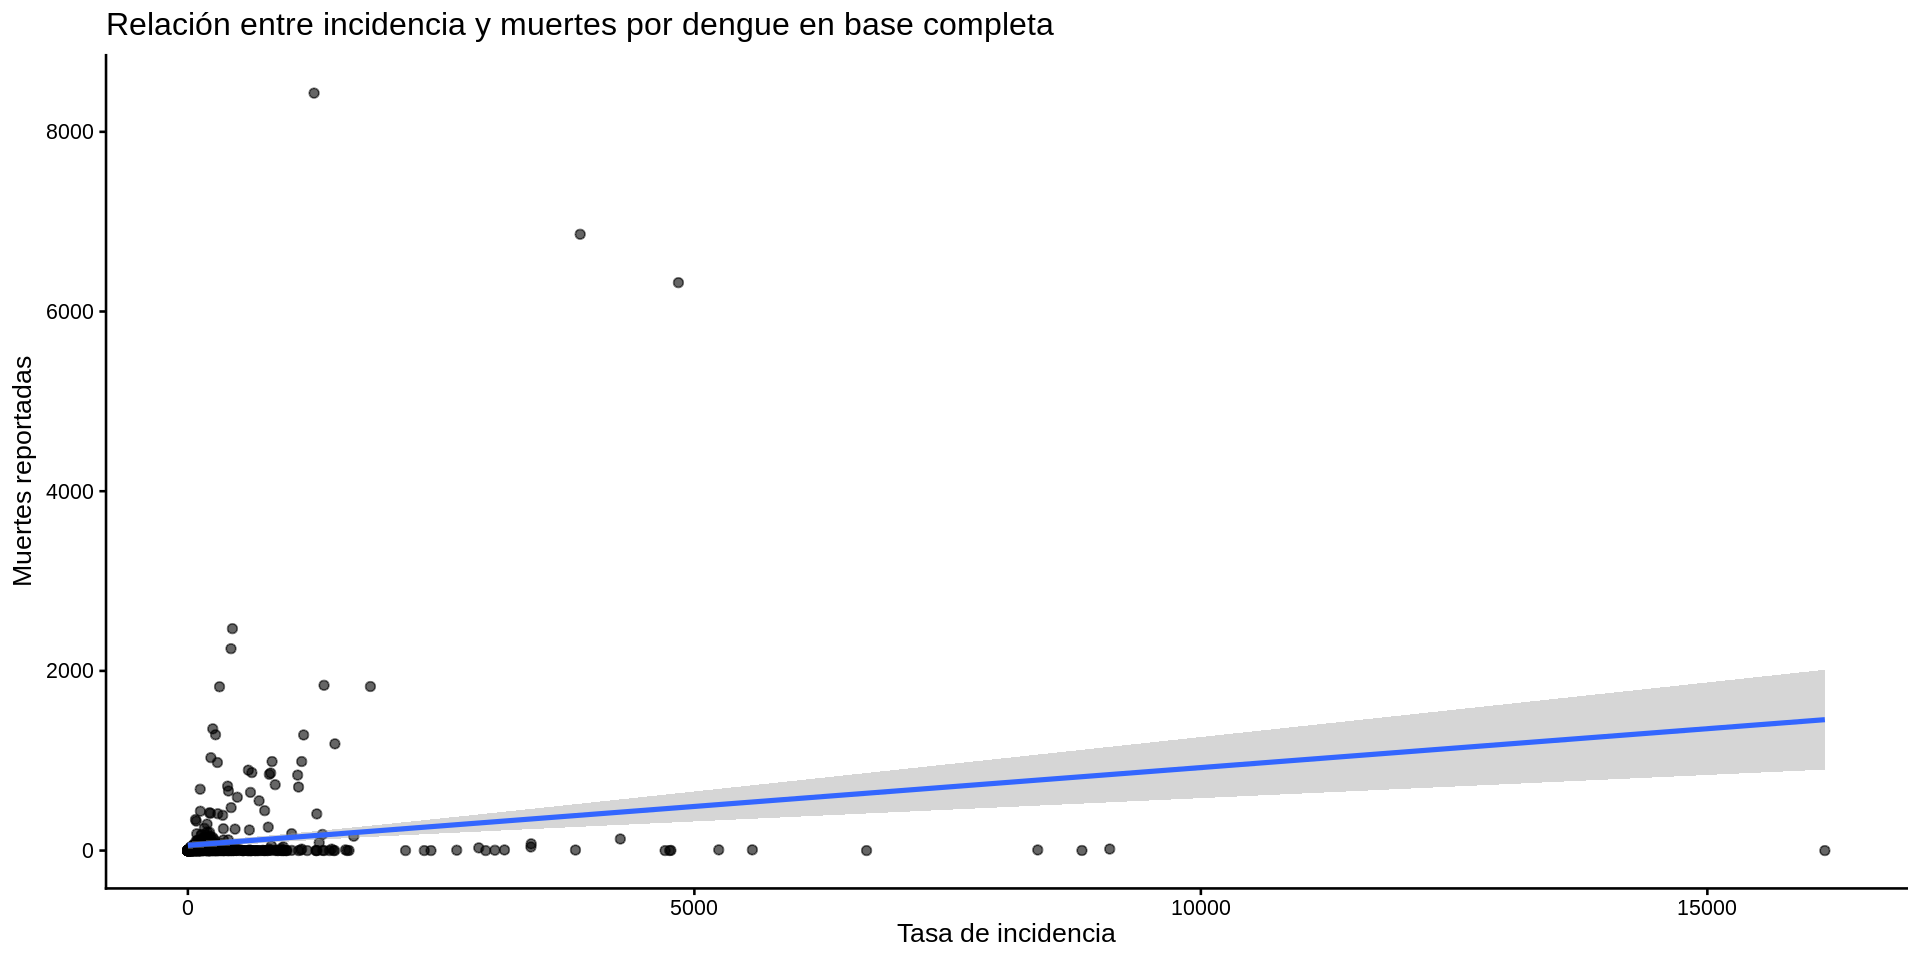

In [107]:
#==========================
# RELACIÓN VISUAL CON DATA COMPLETA
#==========================
ggplot(dengue_clean,
       aes(x = incidence_rate_c,
           y = deaths)) +
  geom_point(alpha = 0.6) +
  geom_smooth(method = "lm", se = TRUE)+
labs(
    title = "Relación entre incidencia y muertes por dengue en base completa",
    x = "Tasa de incidencia",
    y = "Muertes reportadas",
    color = "Consolidado regional"
  ) +
  scale_color_brewer(palette = "Dark2") +
  theme_classic(base_size = 16)

`geom_smooth()` using formula = 'y ~ x'


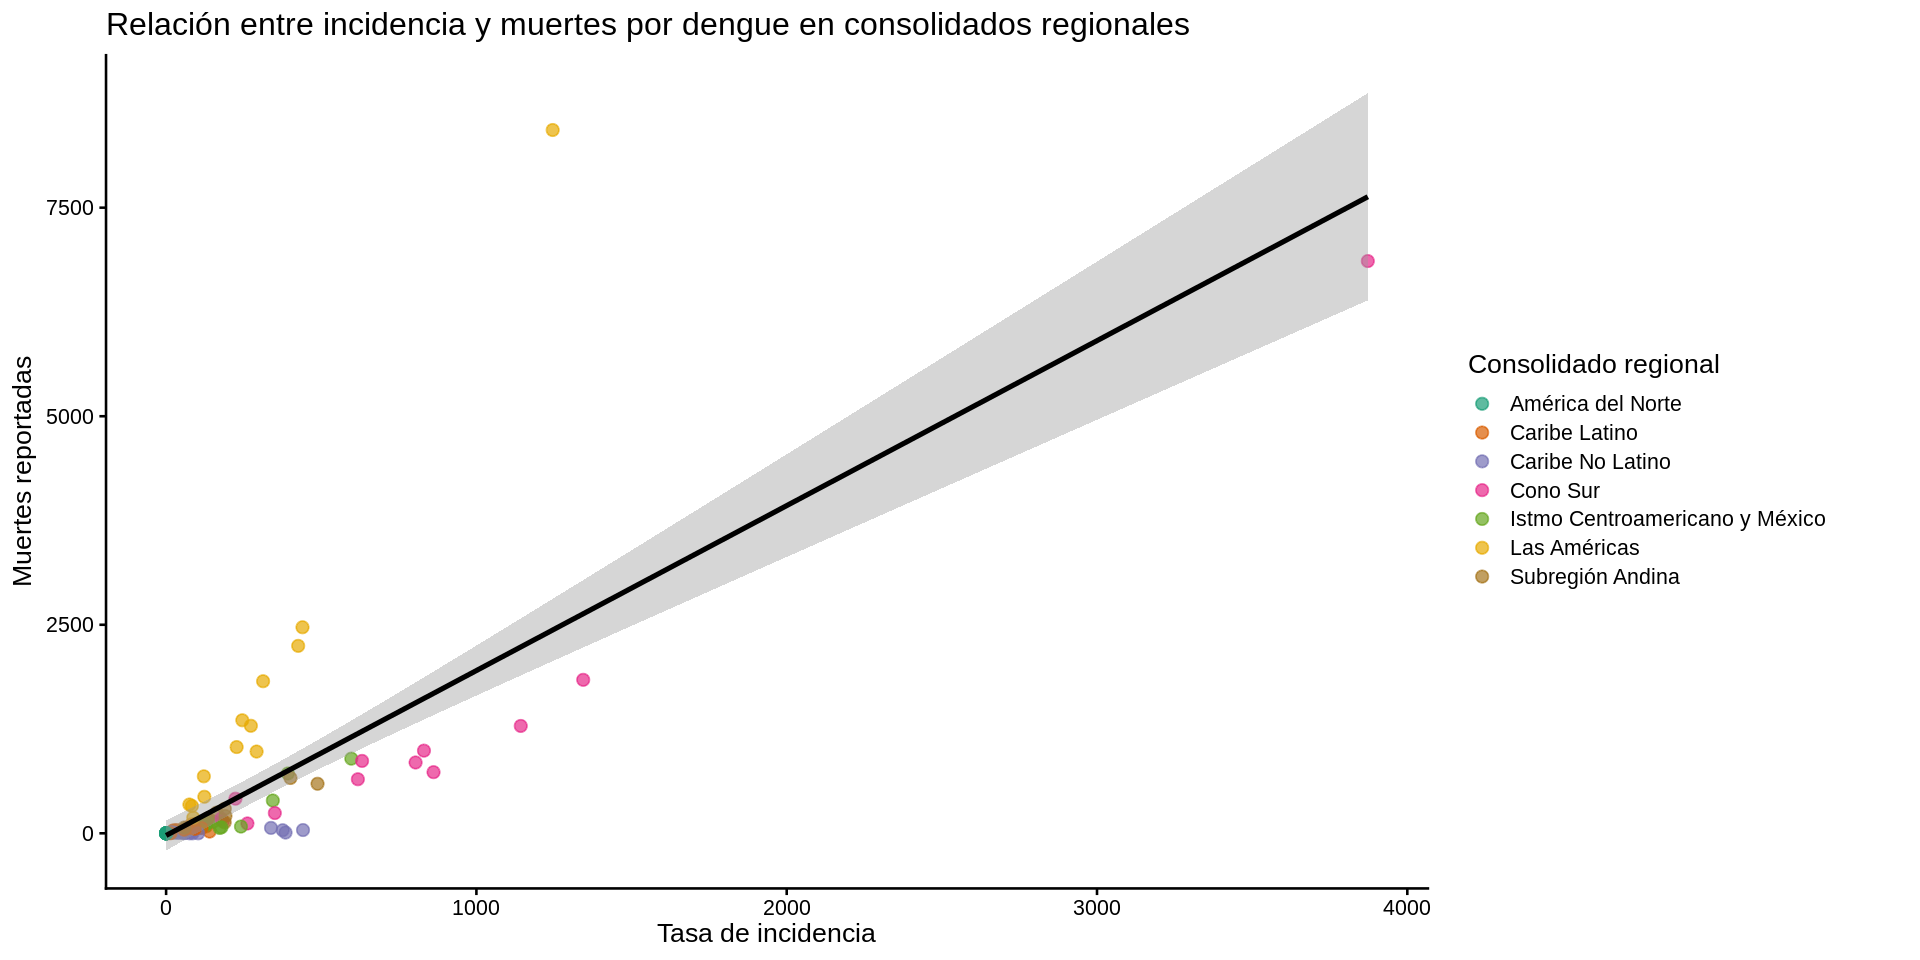

In [104]:
#==========================
# RELACIÓN VISUAL REGIONAL
#==========================

options(repr.plot.width = 16, repr.plot.height = 8)

ggplot(dengue_regional,
       aes(x = incidence_rate_c,
           y = deaths,
           color = country_sp)) +
  geom_point(size = 3, alpha = 0.7) +
  geom_smooth(method = "lm", se = TRUE, color = "black") +
  labs(
    title = "Relación entre incidencia y muertes por dengue en consolidados regionales",
    x = "Tasa de incidencia",
    y = "Muertes reportadas",
    color = "Consolidado regional"
  ) +
  scale_color_brewer(palette = "Dark2") +
  theme_classic(base_size = 16)

Al comparar la relación entre tasa de incidencia y muertes reportadas utilizando la base completa, se observó una alta dispersión de los datos, debido a que la variable country_sp incluye simultáneamente países, territorios y consolidados regionales. Esta mezcla de niveles geográficos dificulta la interpretación directa de la relación entre ambas variables, ya que los registros regionales presentan magnitudes naturalmente superiores a las de países individuales.

Por esta razón, se realizó un análisis complementario considerando únicamente los registros clasificados como “Consolidado regional”. En este nivel de análisis, la relación visual entre incidencia y muertes se observa con mayor claridad, mostrando una tendencia positiva entre ambas variables. No obstante, la presencia de valores extremos sugiere que la interpretación debe realizarse con cautela, ya que algunos consolidados regionales pueden influir fuertemente en la pendiente de la línea de tendencia.

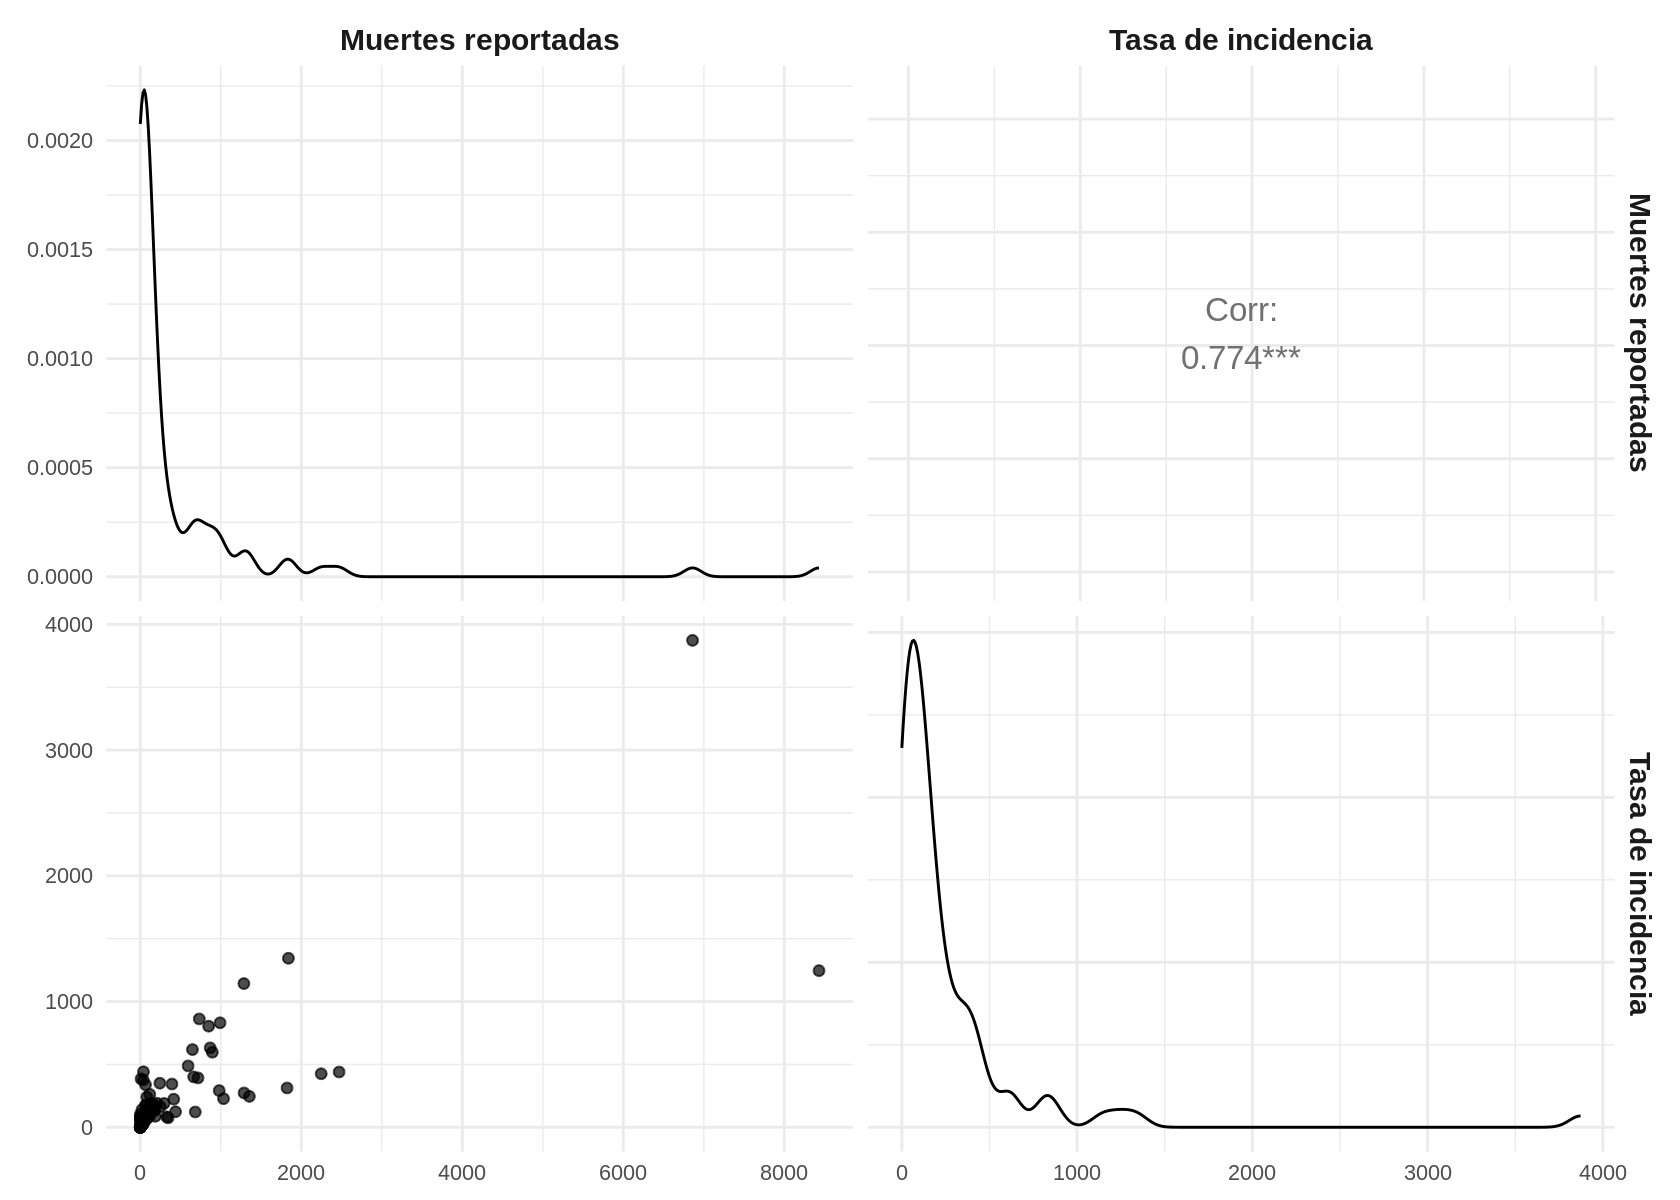

In [111]:
#=============================================
# CORRELACIÓN VISUAL AVANZADA A NIVEL REGIONAL
#=============================================

# Matriz de relación entre Muertes reportadas y Tasa de incidencia de Dengue

options(repr.plot.width = 14, repr.plot.height = 10)

ggpairs(
  datos_regionales_cor,
  upper = list(
    continuous = wrap("cor", size = 7)
  ),
  lower = list(
    continuous = wrap("points", alpha = 0.7, size = 2.5)
  ),
  diag = list(
    continuous = wrap("densityDiag")
  )
) +
  theme_minimal(base_size = 18) +
  theme(
    strip.text = element_text(size = 18, face = "bold"),
    axis.text = element_text(size = 13),
    axis.title = element_text(size = 15, face = "bold")
  )

La matriz de correlación para los consolidados regionales muestra una asociación positiva fuerte entre la tasa de incidencia y las muertes reportadas por dengue, con una correlación aproximada de 0,774. Esto sugiere que, a nivel regional, los registros con mayor incidencia tienden también a presentar mayor mortalidad. No obstante, las distribuciones de ambas variables son asimétricas y presentan valores extremos, por lo que la interpretación de la asociación debe realizarse con cautela.

A continuación se repetirá el análisis, tomando datos solo de países del Cono Sur.

In [112]:
#=============================================
# BASE: PAÍSES DEL CONO SUR
#=============================================

cono_sur_paises <- dengue_clean %>%
  filter(
    id == 4,
    tipo_registro == "País"
  )

  cono_sur_paises %>%
  distinct(country_sp) %>%
  arrange(country_sp)

country_sp
<chr>
Argentina
Brasil
Chile
Paraguay
Uruguay


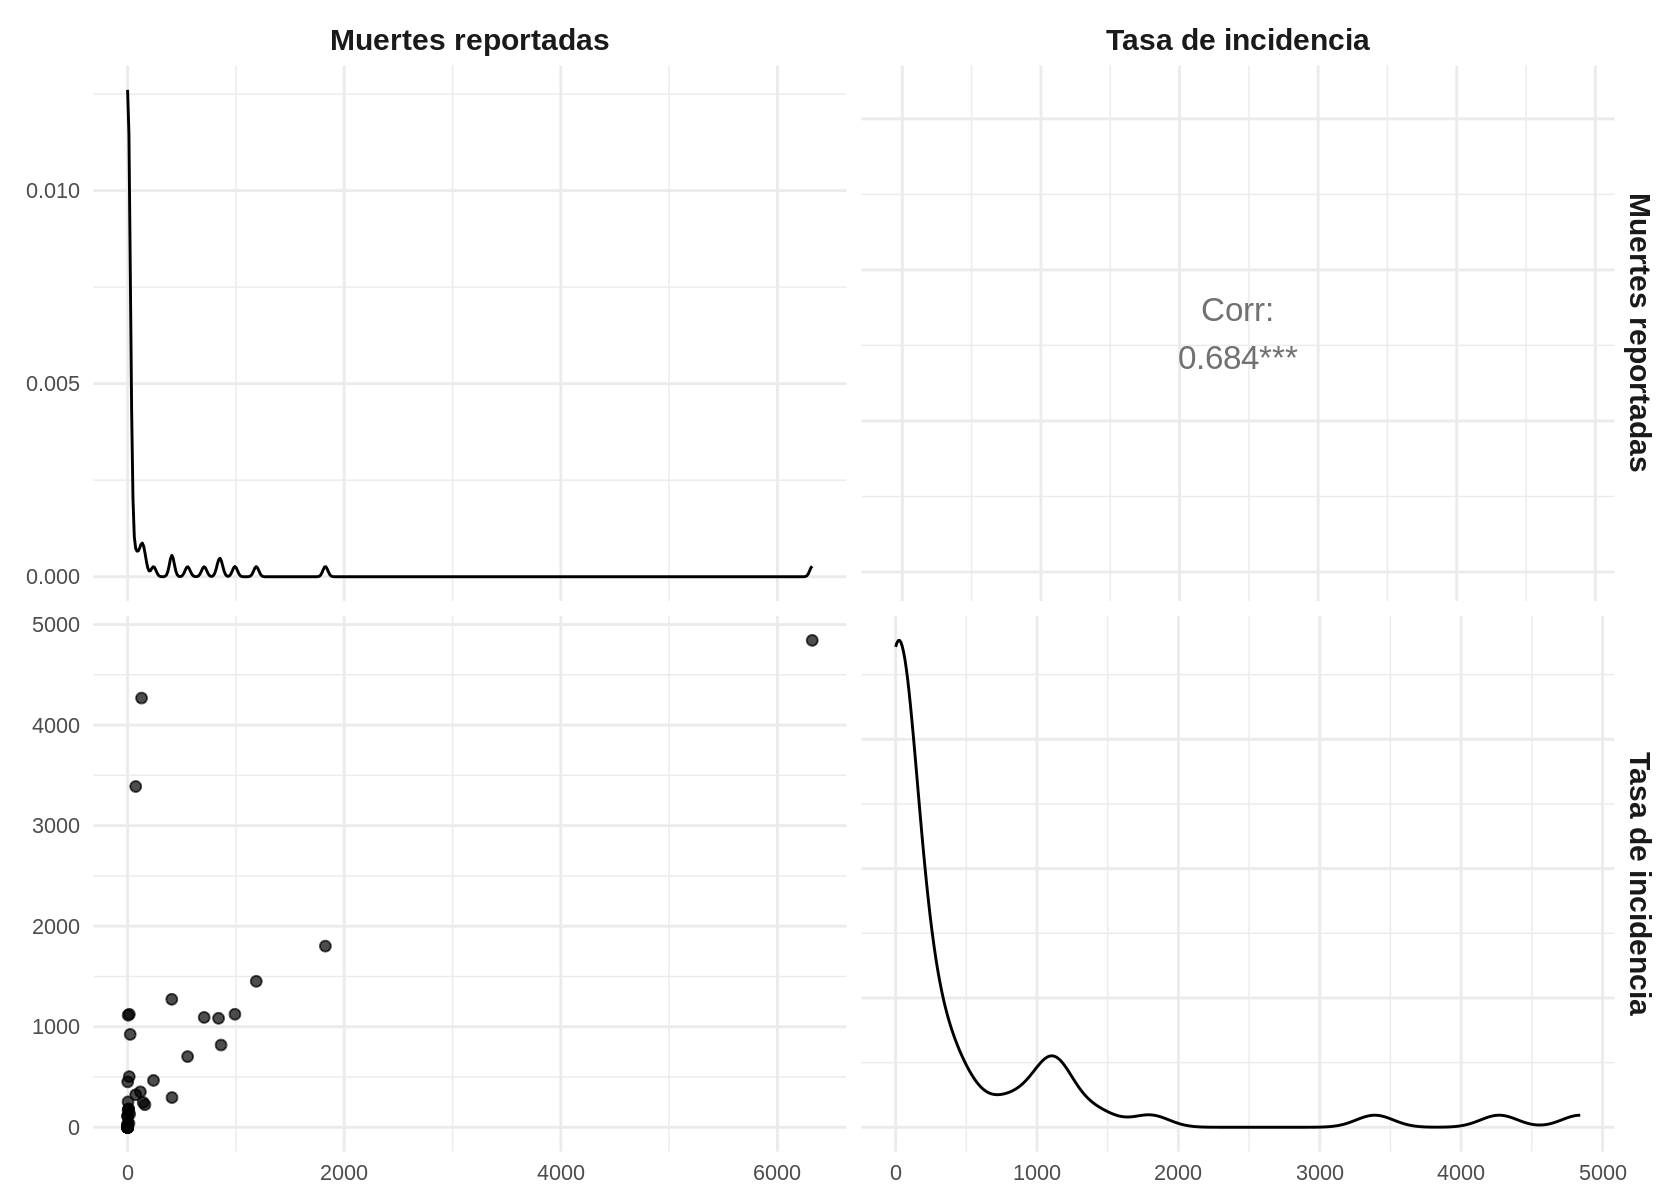

In [113]:
#=============================================
# CORRELACIÓN VISUAL AVANZADA: CONO SUR
#=============================================

options(repr.plot.width = 14, repr.plot.height = 10)

datos_cono_sur_cor <- cono_sur_paises %>%
  select(
    `Muertes reportadas` = deaths,
    `Tasa de incidencia` = incidence_rate_c
  )

ggpairs(
  datos_cono_sur_cor,
  upper = list(
    continuous = wrap("cor", size = 7)
  ),
  lower = list(
    continuous = wrap("points", alpha = 0.7, size = 2.5)
  ),
  diag = list(
    continuous = wrap("densityDiag")
  )
) +
  theme_minimal(base_size = 18) +
  theme(
    strip.text = element_text(size = 18, face = "bold"),
    axis.text = element_text(size = 13),
    axis.title = element_text(size = 15, face = "bold")
  )

In [121]:
# Correlación de Pearson
cor.test(
  cono_sur_paises$incidence_rate_c,
  cono_sur_paises$deaths,
  method = "pearson"
)


	Pearson's product-moment correlation

data:  cono_sur_paises$incidence_rate_c and cono_sur_paises$deaths
t = 7.4505, df = 63, p-value = 3.266e-10
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.5287580 0.7955057
sample estimates:
     cor 
0.684395 


In [129]:
# Modelo de regresión 1 - Dengue con todos los datos
modelo_lm <- lm(
  deaths ~ incidence_rate_c,
  data = dengue_clean

summary(modelo_lm)


Call:
lm(formula = deaths ~ incidence_rate_c, data = dengue_clean)

Residuals:
    Min      1Q  Median      3Q     Max 
-1457.0   -70.0   -59.3   -58.4  8264.8 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)      58.38374   20.19424   2.891  0.00395 ** 
incidence_rate_c  0.08655    0.01788   4.841 1.58e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 512.1 on 717 degrees of freedom
Multiple R-squared:  0.03166,	Adjusted R-squared:  0.03031 
F-statistic: 23.44 on 1 and 717 DF,  p-value: 1.579e-06


In [141]:
# Modelo de regresión 2 - Dengue a nivel regional
modelo_lm2 <- lm(
  deaths ~ incidence_rate_c,
  data = dengue_regional)

summary(modelo_lm2)


Call:
lm(formula = deaths ~ incidence_rate_c, data = dengue_regional)

Residuals:
   Min     1Q Median     3Q    Max 
-946.8 -185.3  -53.2   25.3 5993.8 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)      -25.9278    91.1659  -0.284    0.777    
incidence_rate_c   1.9772     0.1713  11.541   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 764.8 on 89 degrees of freedom
Multiple R-squared:  0.5995,	Adjusted R-squared:  0.595 
F-statistic: 133.2 on 1 and 89 DF,  p-value: < 2.2e-16


`geom_smooth()` using formula = 'y ~ x'


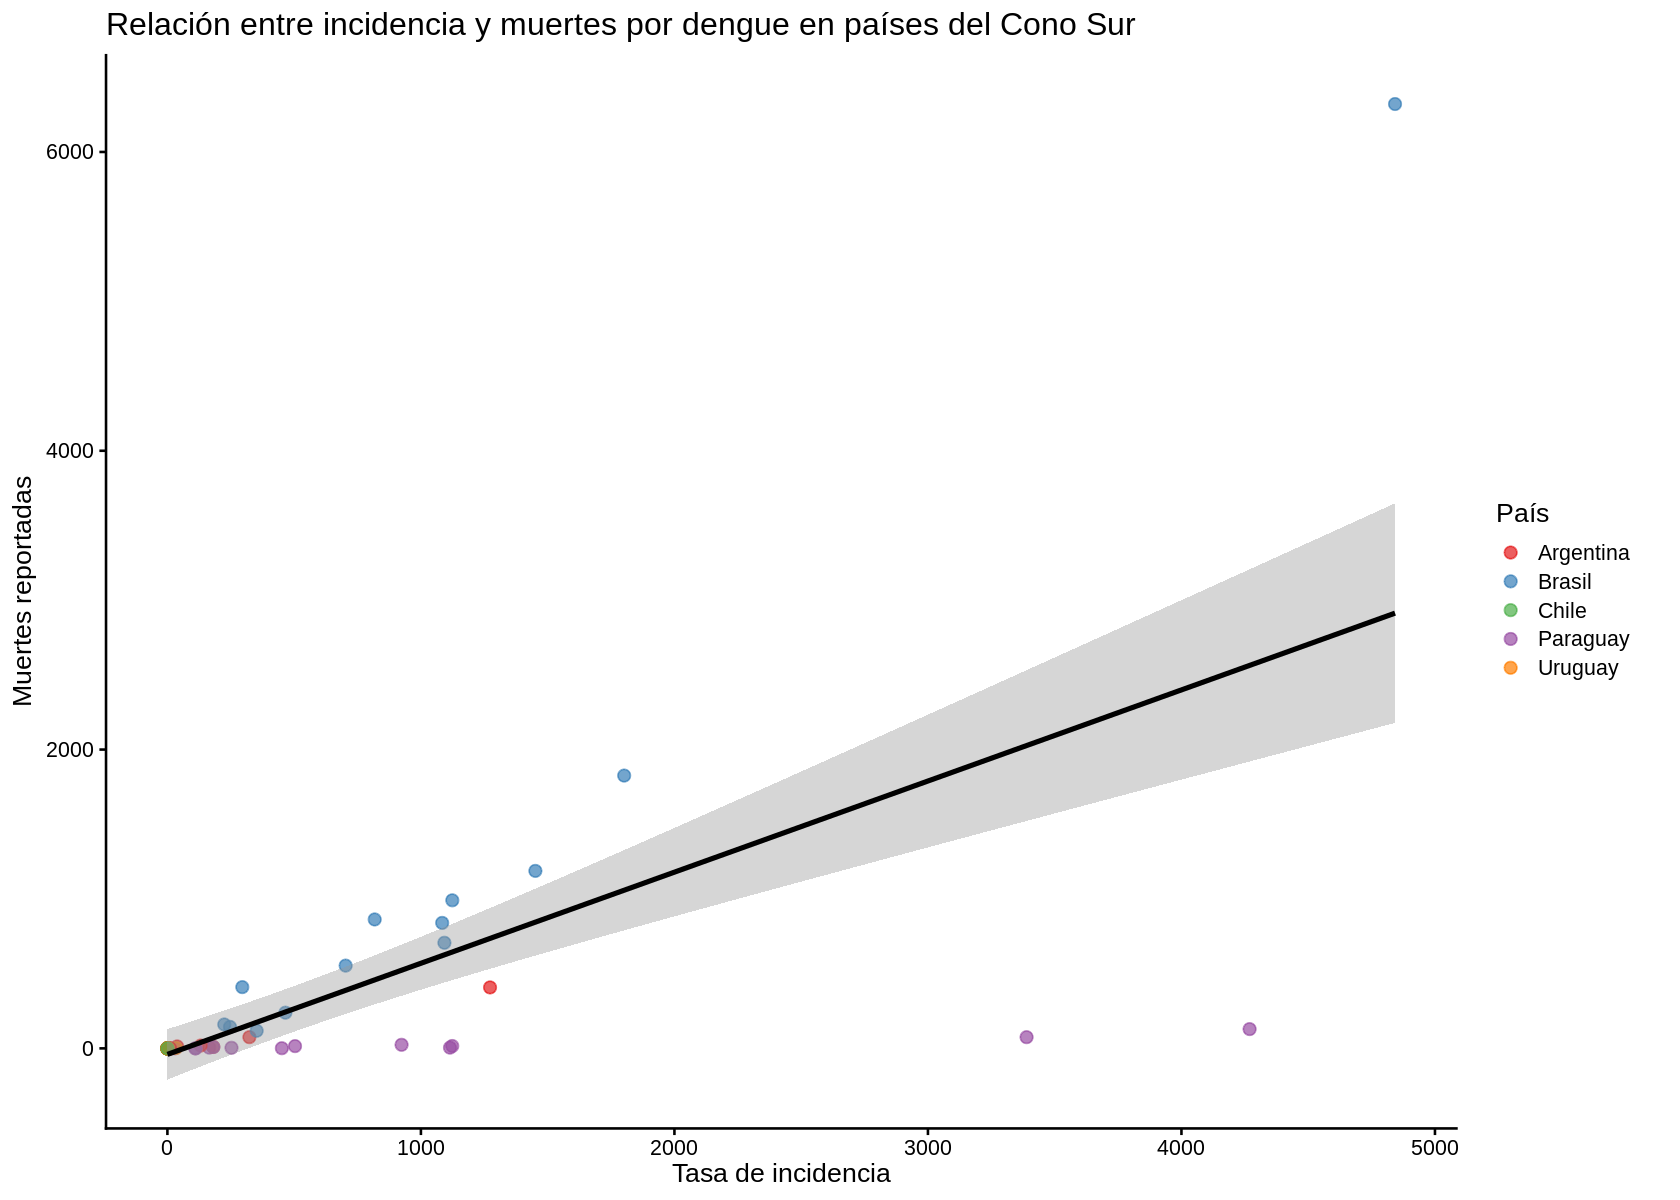

In [116]:
ggplot(cono_sur_paises,
       aes(x = incidence_rate_c,
           y = deaths,
           color = country_sp)) +
  geom_point(size = 3, alpha = 0.7) +
  geom_smooth(method = "lm", se = TRUE, color = "black") +
  labs(
    title = "Relación entre incidencia y muertes por dengue en países del Cono Sur",
    x = "Tasa de incidencia",
    y = "Muertes reportadas",
    color = "País"
  ) +
  scale_color_brewer(palette = "Set1") +
  theme_classic(base_size = 16)

En el análisis de países del Cono Sur, Brasil concentra los registros con mayores valores de incidencia y muertes reportadas, por lo que influye de manera importante en la tendencia positiva observada. Por otro lado al ver los registros de Paraguay, da un interesante dato dado que a mayor incidencia no siempre se traduce proporcionalmente en mayor número de muertes.

In [120]:
# Tabla de Top 10 de muertes registradas por país y año
#Esta tabla tiene por objetivo detectar los valores extremos altos del análisis
top10_muertes_cono_sur_presentacion <- top10_muertes_cono_sur %>%
  rename(
    País = country_sp,
    Año = year,
    `Tasa de incidencia` = incidence_rate_c,
    `Muertes reportadas` = deaths,
    `Casos confirmados` = confirmed
  )

top10_muertes_cono_sur_presentacion

,País,Año,Tasa de incidencia,Muertes reportadas,Casos confirmados
,<chr>,<int>,<dbl>,<int>,<int>
1,Brasil,2024,4842.51,6321,5973340
2,Brasil,2025,1801.76,1826,1469805
3,Brasil,2023,1451.52,1188,1417218
4,Brasil,2022,1123.83,991,1210760
5,Brasil,2015,817.66,863,500972
6,Brasil,2019,1083.88,840,1290861
7,Brasil,2016,1092.66,707,1039147
8,Brasil,2020,703.13,554,765114
9,Brasil,2014,295.41,410,220539


Al profundizar el análisis en los países del Cono Sur, se observó una correlación positiva entre la tasa de incidencia y las muertes reportadas, aunque menor que la observada a nivel de consolidados regionales. El gráfico de dispersión permitió identificar que Brasil concentra los registros con mayores valores de muertes, incidencia y casos confirmados, influyendo de manera relevante en la tendencia general del grupo. Esta observación fue confirmada mediante la tabla de los diez registros con mayor número de muertes, donde Brasil concentró nueve de los diez valores más altos, destacando especialmente el año 2024 con 6.321 muertes y 5.973.340 casos confirmados. Asimismo, se observó que Argentina aparece en el décimo lugar en 2024, aunque con una magnitud considerablemente menor. Estos resultados refuerzan la idea de que la mortalidad por dengue no depende exclusivamente de la incidencia, sino también de otros factores epidemiológicos, sanitarios y poblacionales.

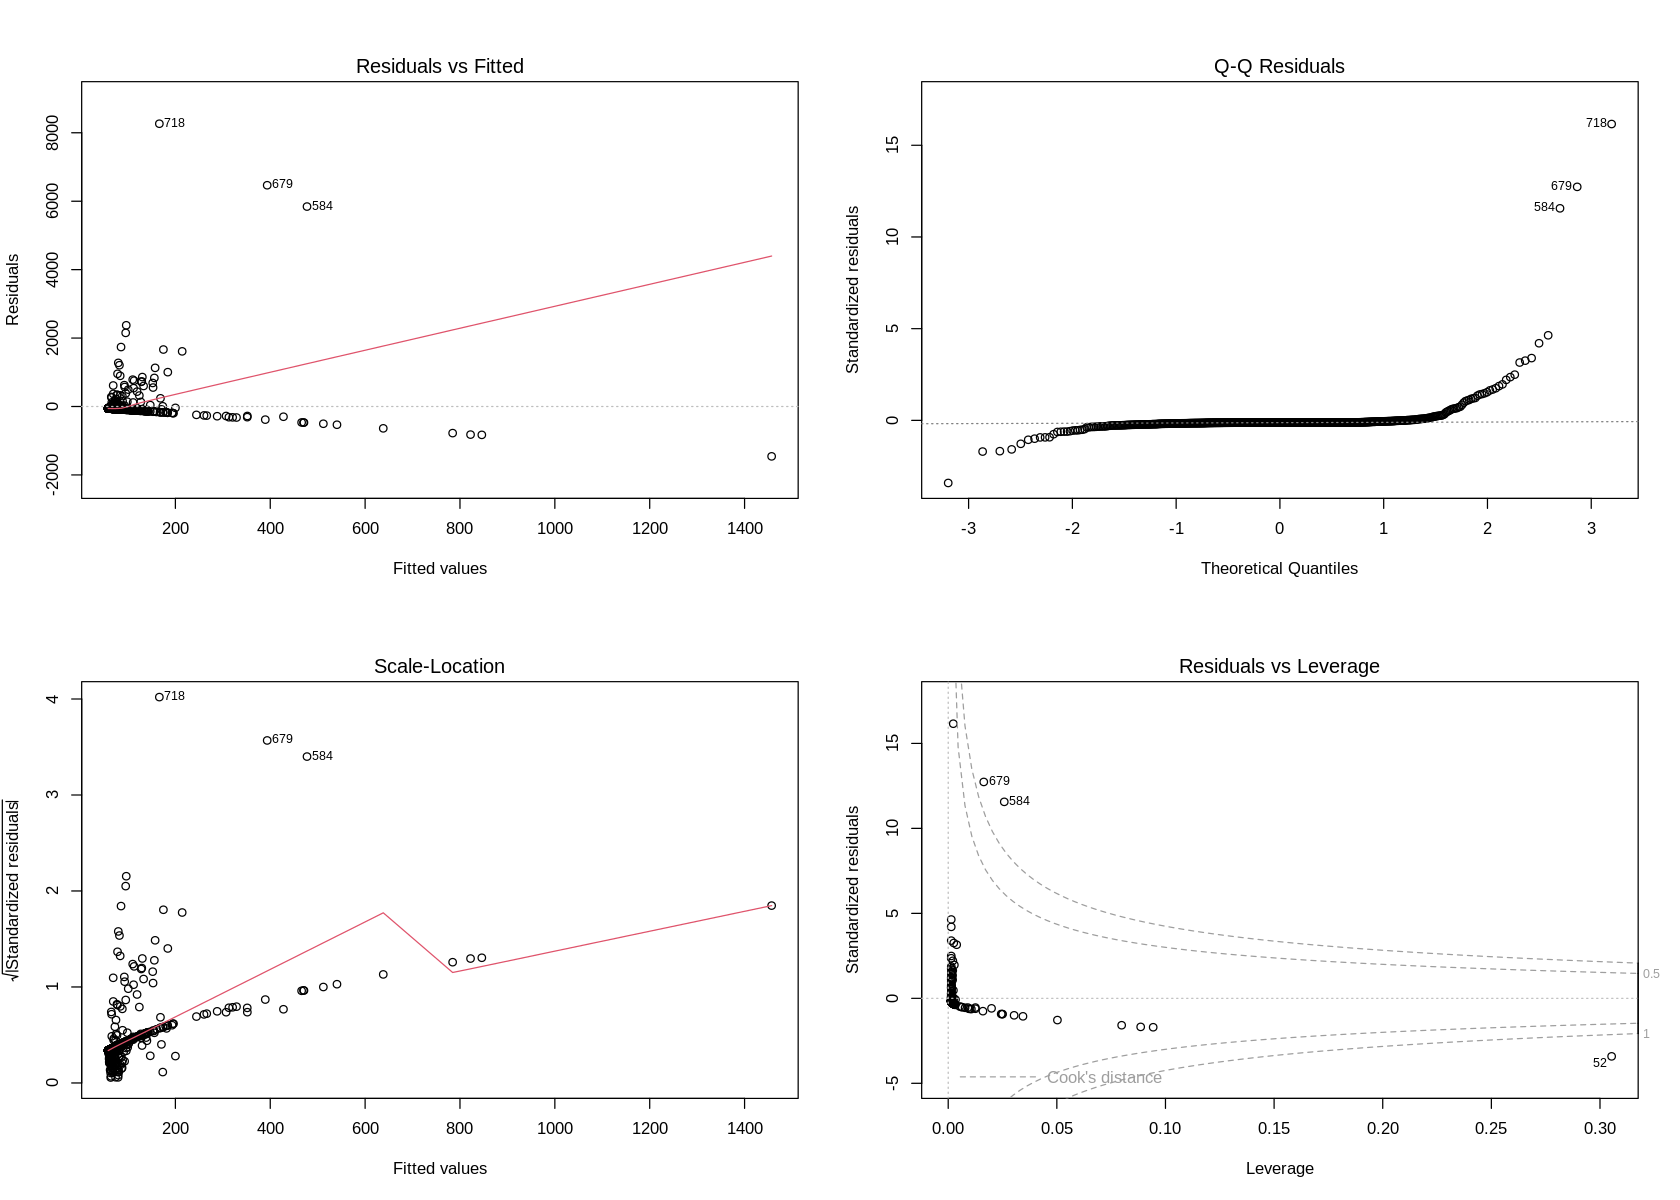

In [124]:
#=============================================
# DIAGNÓSTICO FORMAL DE RESIDUOS Y SUPUESTOS
# Diagnóstico original
#=============================================

# Diagnóstico gráfico para dengue con todo el dataset
par(mfrow = c(2,2))
plot(modelo_lm)




1. Residuals vs Fitted

Este es el gráfico de arriba a la izquierda.

Muestra:

eje X = valores predichos por el modelo
eje Y = residuos, es decir, errores del modelo

Un residuo es la diferencia entre lo observado y lo que el modelo predijo.

Lo ideal sería ver puntos repartidos de forma más o menos aleatoria alrededor de la línea horizontal en cero.

En tu gráfico regional se observa que:

Los puntos no están completamente dispersos al azar. Hay una curva roja que baja y luego se estabiliza, además de algunos residuos muy altos.

Eso sugiere que el modelo lineal no captura completamente el patrón de los datos. Es decir, la relación entre incidencia y muertes puede no ser perfectamente lineal o estar muy afectada por valores extremos.

In [134]:
# Normalidad de residuos
shapiro.test(residuals(modelo_lm))




	Shapiro-Wilk normality test

data:  residuals(modelo_lm)
W = 0.21477, p-value < 2.2e-16


In [135]:

# Heterocedasticidad
library(lmtest)
bptest(modelo_lm)




	studentized Breusch-Pagan test

data:  modelo_lm
BP = 21.422, df = 1, p-value = 3.685e-06


,StudRes,Hat,CookD
,<dbl>,<dbl>,<dbl>
49,-1.703464,0.094344503,0.1507436
52,-3.439605,0.305355416,2.5616442
584,12.808754,0.025799725,1.7699274
679,14.463157,0.016367254,1.3487473
718,20.249734,0.002331538,0.3050884


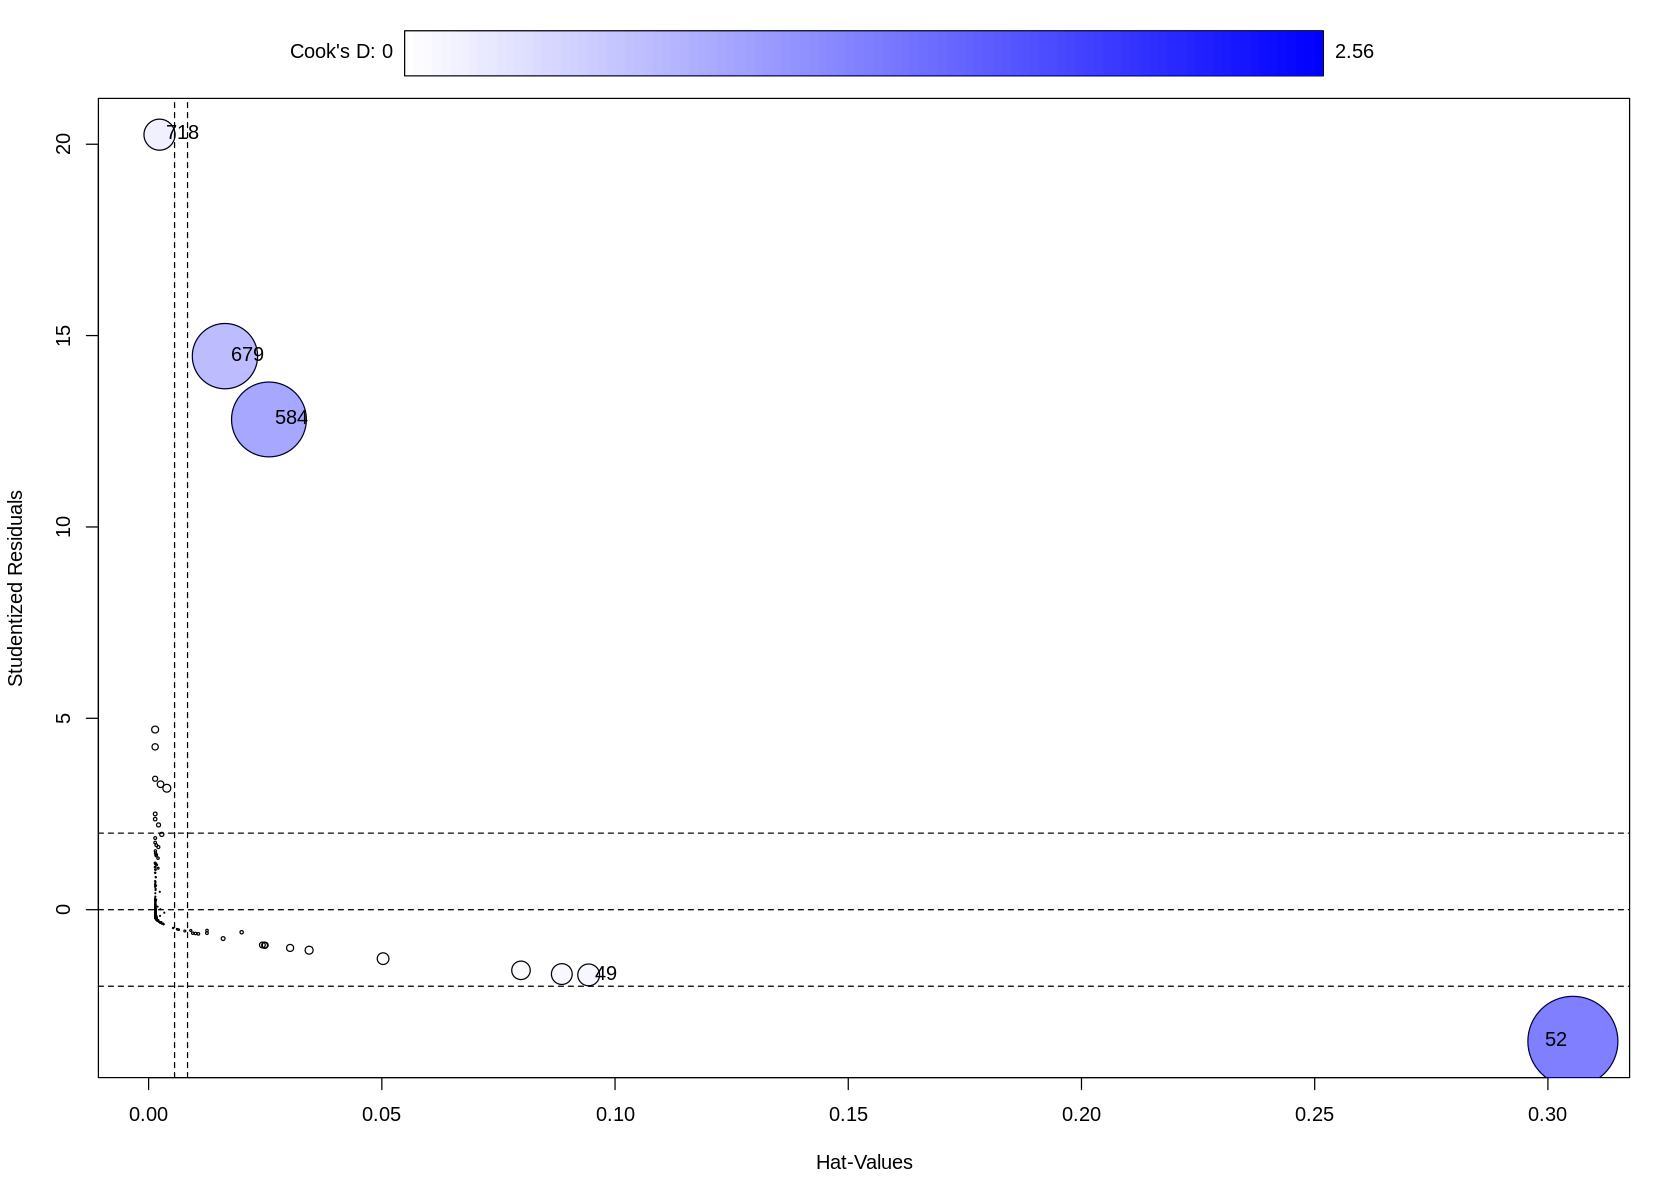

In [136]:
# Observaciones influyentes
library(car)
influencePlot(modelo_lm)

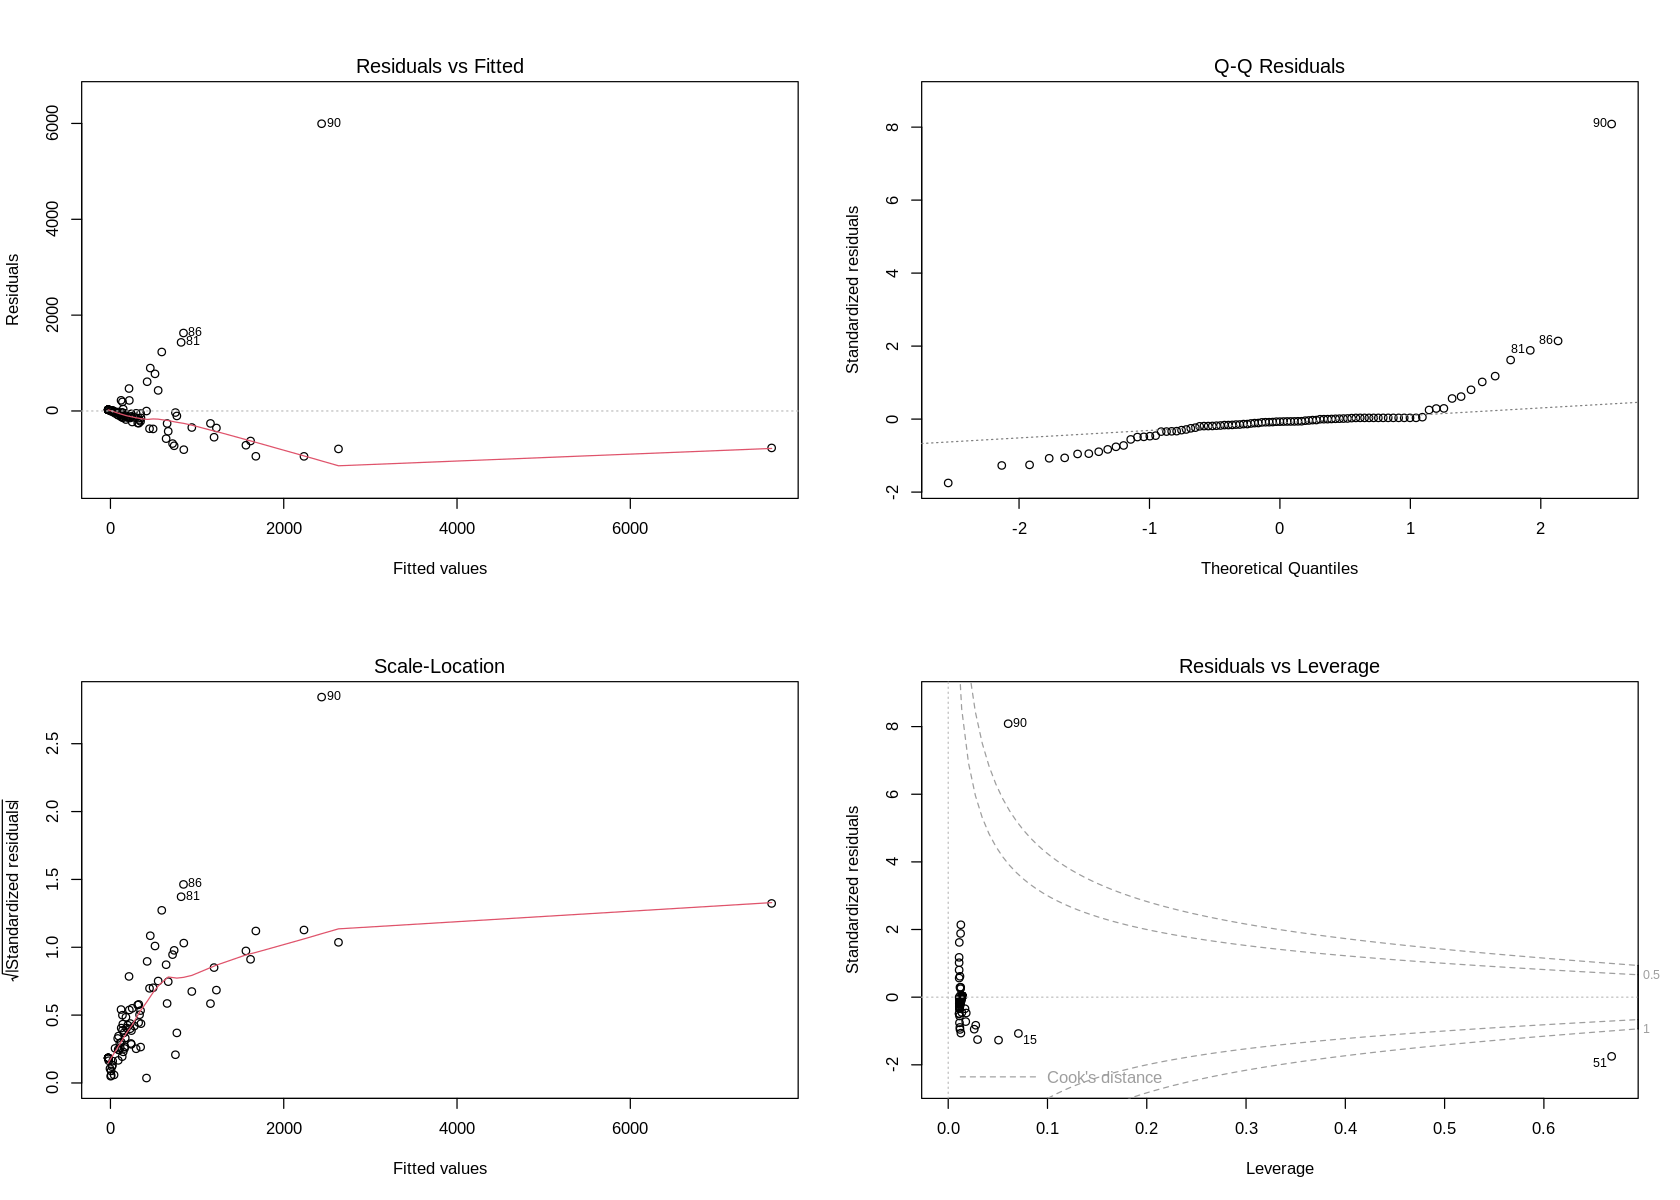

In [137]:
#=============================================
# DIAGNÓSTICO FORMAL DE RESIDUOS Y SUPUESTOS
# Diagnóstico regional
#=============================================

par(mfrow = c(2,2))
plot(modelo_lm2)

**1. Residuals vs Fitted**

Este es el gráfico de arriba a la izquierda.

Muestra:

eje X = valores predichos por el modelo
eje Y = residuos, es decir, errores del modelo

Un residuo es la diferencia entre lo observado y lo que el modelo predijo.

Lo ideal sería ver puntos repartidos de forma más o menos aleatoria alrededor de la línea horizontal en cero.

En el gráfico regional se observa que:

- Los puntos no están completamente dispersos al azar. Hay una curva roja que baja y luego se estabiliza, además de algunos residuos muy altos.

- Eso sugiere que el modelo lineal no captura completamente el patrón de los datos. Es decir, la relación entre incidencia y muertes puede no ser perfectamente lineal o estar muy afectada por valores extremos.

**2. Q-Q Residuals**

Este es el gráfico de arriba a la derecha y sirve para revisar si los residuos siguen una distribución normal.

Lo ideal sería que los puntos siguieran bastante bien la línea diagonal punteada.

En este caso: los puntos se separan mucho de la línea en el extremo superior, especialmente un punto muy extremo. Eso indica que los residuos no siguen una distribución normal.

Esto se confirma con la prueba de Shapiro-Wilk:

> p-value = 4.523e-16


Como el p-value es menor que 0.05, se rechaza la normalidad de los residuos.

Por lo tanto: los errores del modelo regional no tienen distribución normal.

.\
**3. Scale-Location**

Este es el gráfico de abajo a la izquierda.

Sirve para revisar la homocedasticidad, o sea, si la variabilidad de los errores es más o menos constante a lo largo del modelo.

Lo ideal sería que la línea roja fuera relativamente horizontal y que los puntos tuvieran una dispersión similar en todo el eje X.

En este gráfico se observa que la línea roja sube y los puntos se abren más en ciertos tramos. Eso sugiere heterocedasticidad, es decir, la variabilidad de los errores no es constante.

Esto se confirma con Breusch-Pagan:

>p-value = 0.0128

Como es menor a 0.05, hay evidencia de heterocedasticidad.

Por lo tanto, el modelo se equivoca con distinta intensidad según el nivel de incidencia. No tiene errores parejos.

**4. Residuals vs Leverage**

Este es el gráfico de abajo a la derecha.

Este revisa observaciones influyentes, es decir, puntos que tienen mucho peso sobre el modelo.

Aquí aparecen observaciones como:

- 15
- 51
- 86
- 90

Y en la tabla de influencePlot() viste:


90 | StudRes = 15.601344  |CookD = 2.10122002\
51 | Hat = 0.66823334     | CookD = 3.08521394

Esto es muy importante.

La observación 90 tiene un residuo estandarizado altísimo. Eso significa que el modelo se equivoca muchísimo en ese registro.

La observación 51 tiene un leverage muy alto. Eso significa que está en una zona muy extrema de la variable predictora y puede influir mucho en la forma de la recta.

Cook’s Distance alto indica que esas observaciones pueden cambiar bastante el modelo si se eliminan o revisan.

En simple:

El modelo regional está muy influido por algunos registros extremos.

In [138]:
# Normalidad de residuos
shapiro.test(residuals(modelo_lm2))


	Shapiro-Wilk normality test

data:  residuals(modelo_lm2)
W = 0.49961, p-value = 4.523e-16


In [139]:
# Heterocedasticidad
library(lmtest)
bptest(modelo_lm2)


	studentized Breusch-Pagan test

data:  modelo_lm2
BP = 6.1962, df = 1, p-value = 0.0128


,StudRes,Hat,CookD
,<dbl>,<dbl>,<dbl>
15,-1.074854,0.07069355,0.04386644
51,-1.771179,0.66823334,3.08521394
86,2.185927,0.01272790,0.02954640
90,15.601344,0.06040635,2.10122002


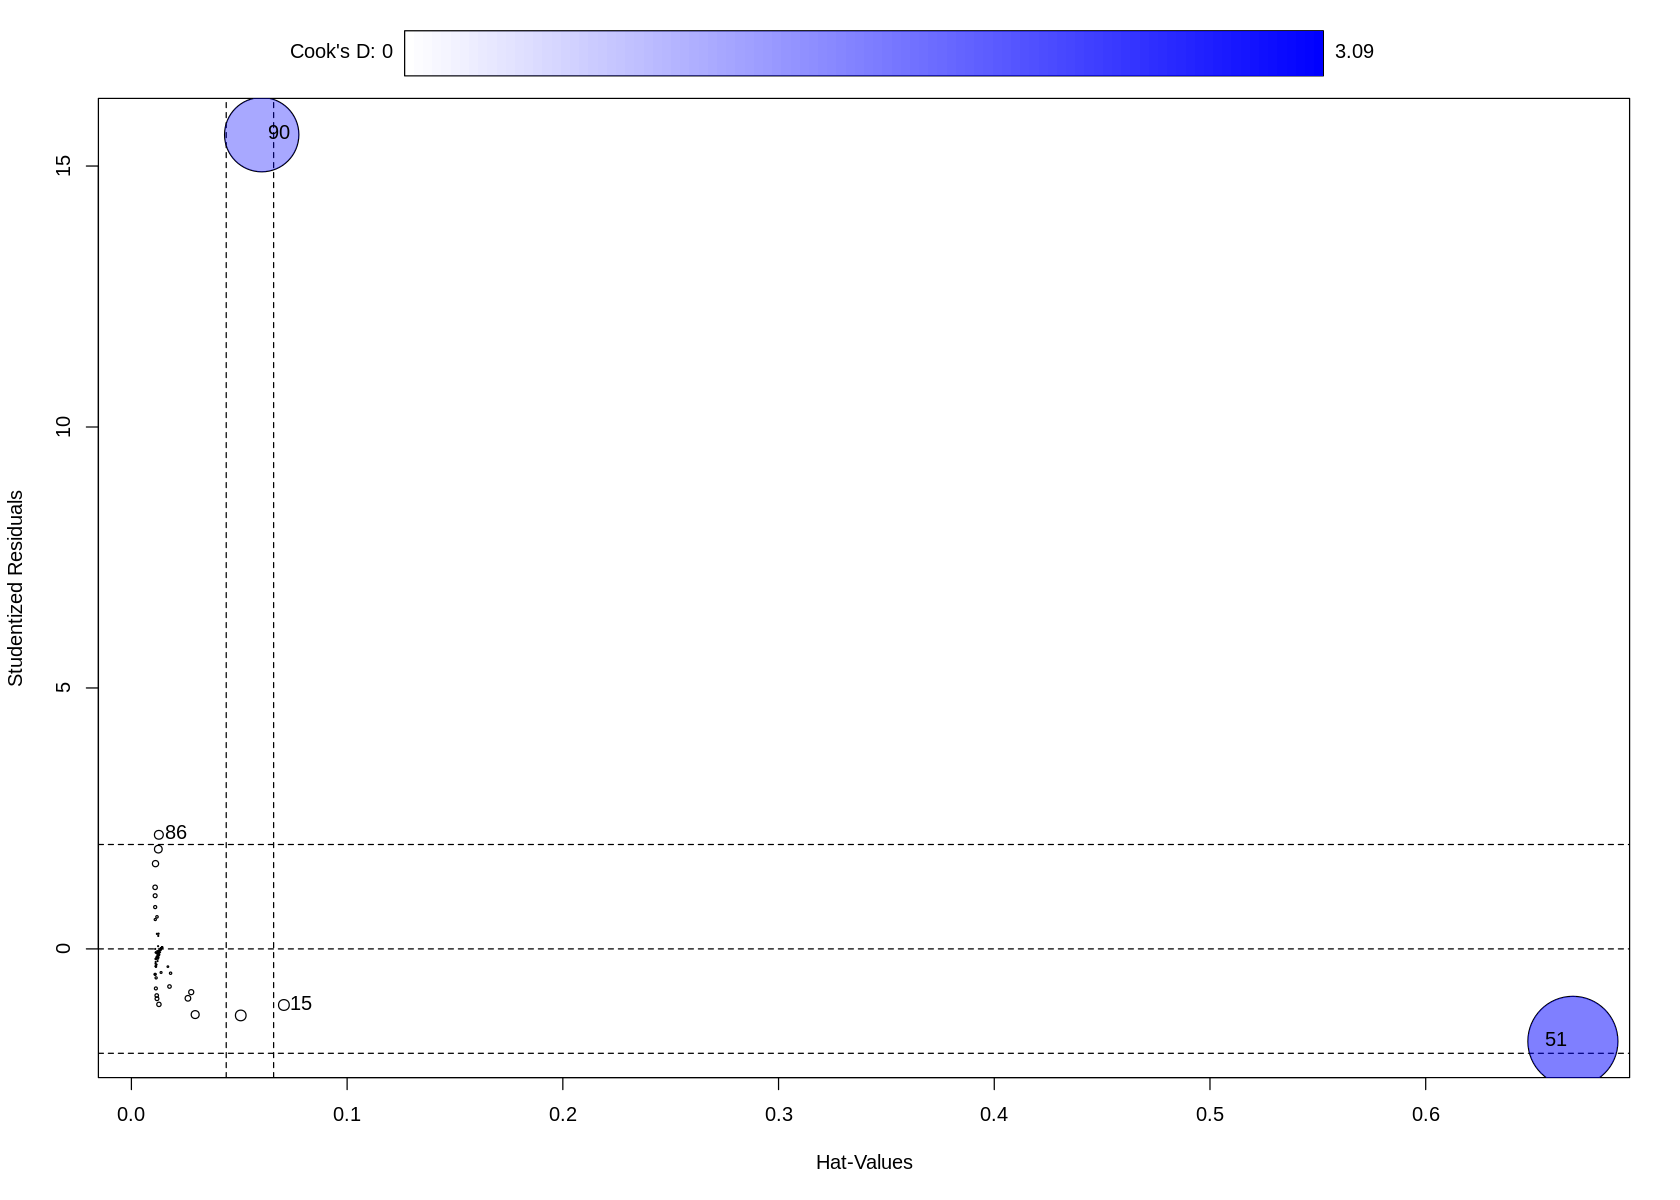

In [140]:
# Observaciones influyentes
library(car)
influencePlot(modelo_lm2)


En el análisis regional, el modelo de regresión lineal simple permite observar una tendencia positiva entre la tasa de incidencia y las muertes reportadas. Sin embargo, los diagnósticos del modelo evidencian problemas de normalidad de residuos, heterocedasticidad y presencia de observaciones influyentes. Por ello, el modelo debe interpretarse con cautela y utilizarse principalmente como una aproximación exploratoria.

In [142]:
modelo_log <- lm(
  log1p(deaths) ~ log1p(incidence_rate_c),
  data = dengue_regional
)

summary(modelo_log)


Call:
lm(formula = log1p(deaths) ~ log1p(incidence_rate_c), data = dengue_regional)

Residuals:
    Min      1Q  Median      3Q     Max 
-4.4019 -0.2439  0.2787  0.5502  1.9696 

Coefficients:
                        Estimate Std. Error t value Pr(>|t|)    
(Intercept)             -0.59876    0.32434  -1.846   0.0682 .  
log1p(incidence_rate_c)  1.07583    0.06802  15.817   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.306 on 89 degrees of freedom
Multiple R-squared:  0.7376,	Adjusted R-squared:  0.7347 
F-statistic: 250.2 on 1 and 89 DF,  p-value: < 2.2e-16



	Shapiro-Wilk normality test

data:  residuals(modelo_log)
W = 0.85859, p-value = 7.592e-08



	studentized Breusch-Pagan test

data:  modelo_log
BP = 1.4501, df = 1, p-value = 0.2285


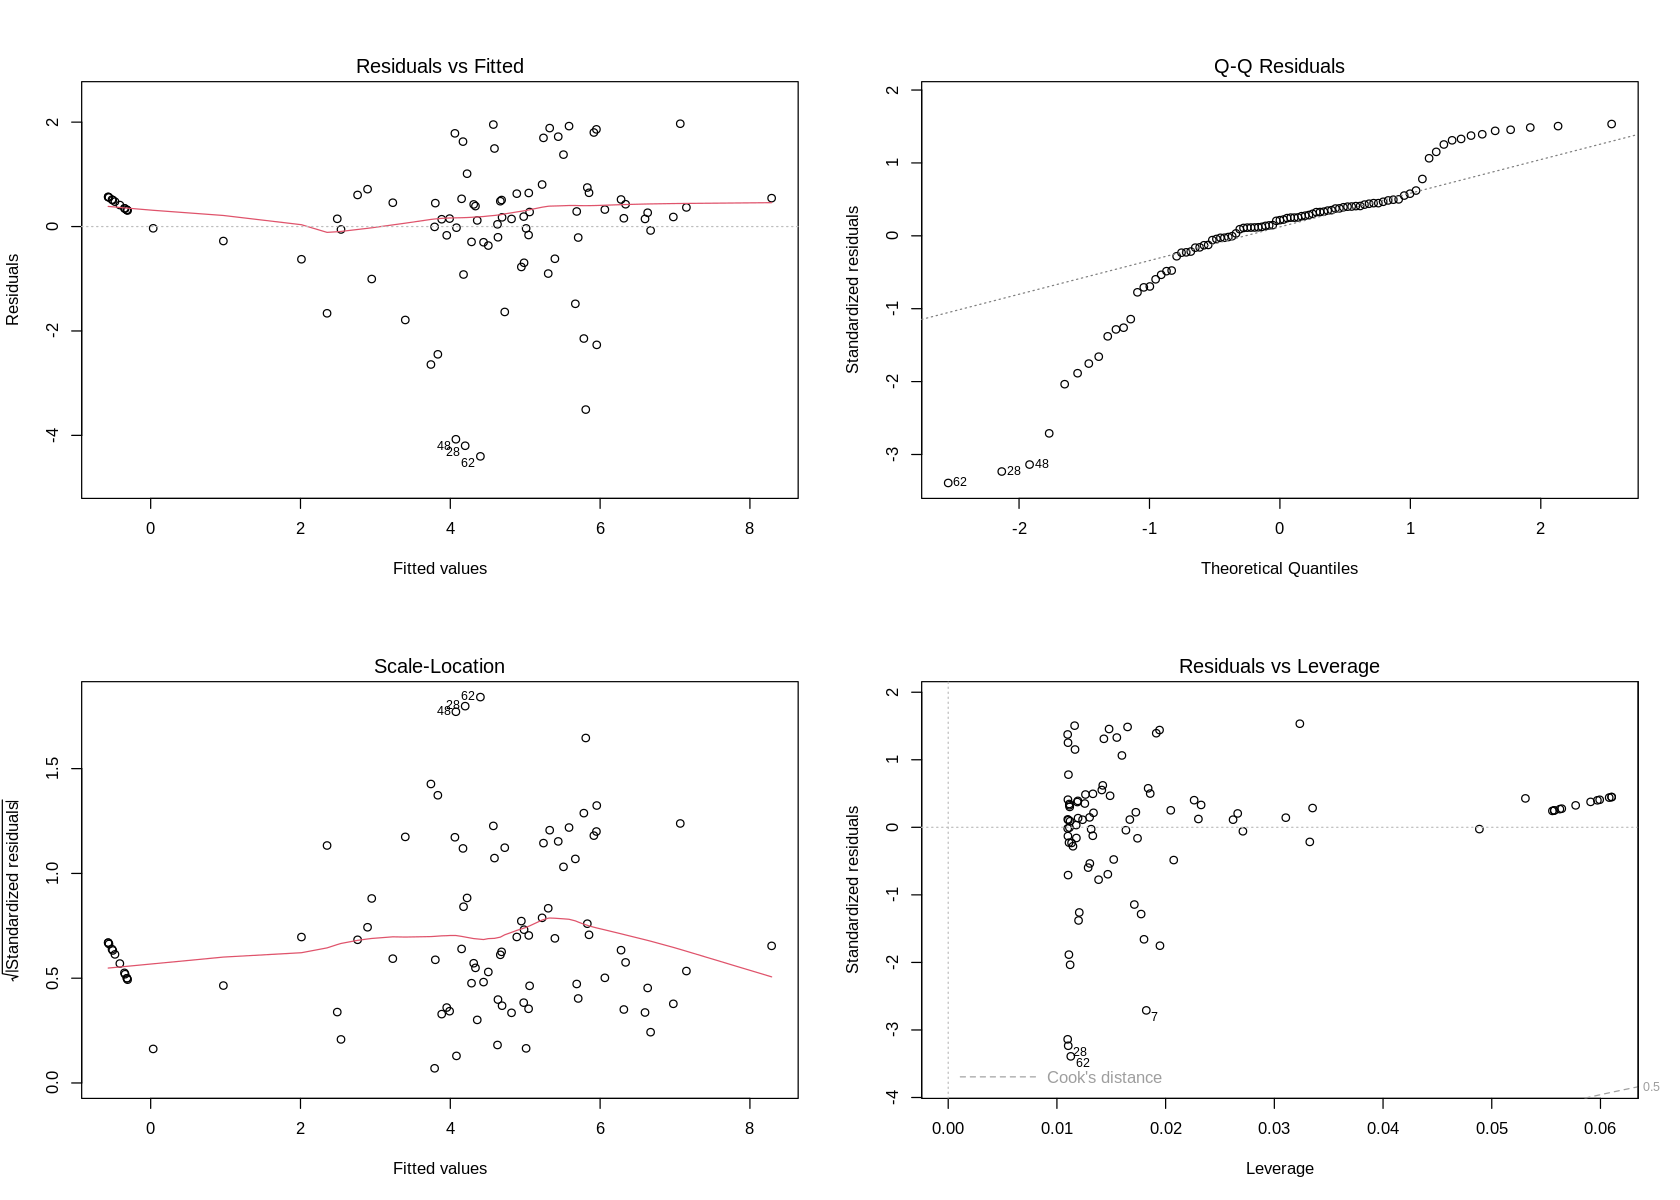

In [143]:
par(mfrow = c(2,2))
plot(modelo_log)
par(mfrow = c(1,1))

shapiro.test(residuals(modelo_log))

library(lmtest)
bptest(modelo_log)

El modelo lineal simple original mostró problemas importantes de normalidad, heterocedasticidad y observaciones influyentes. Al aplicar una transformación logarítmica a las variables, el comportamiento del modelo mejoró, especialmente respecto a la homocedasticidad, ya que la prueba de Breusch-Pagan dejó de ser significativa. Sin embargo, la normalidad de los residuos aún no se cumple completamente, por lo que el modelo logarítmico debe interpretarse con cautela.

--

Dado que las variables epidemiológicas presentaron alta asimetría y valores extremos, se ajustó un modelo lineal con transformación logarítmica. Este modelo mostró una mejora respecto al modelo lineal simple, especialmente en la estabilidad de la varianza de los residuos. No obstante, la prueba de normalidad continuó siendo significativa, por lo que los resultados se interpretan como una aproximación exploratoria y no como un modelo predictivo definitivo.

# Análisis por países

In [146]:
#=============================================
# BASE A NIVEL PAÍS / TERRITORIO
#=============================================

dengue_paises <- dengue_clean %>%
  filter(tipo_registro == "País")

`geom_smooth()` using formula = 'y ~ x'


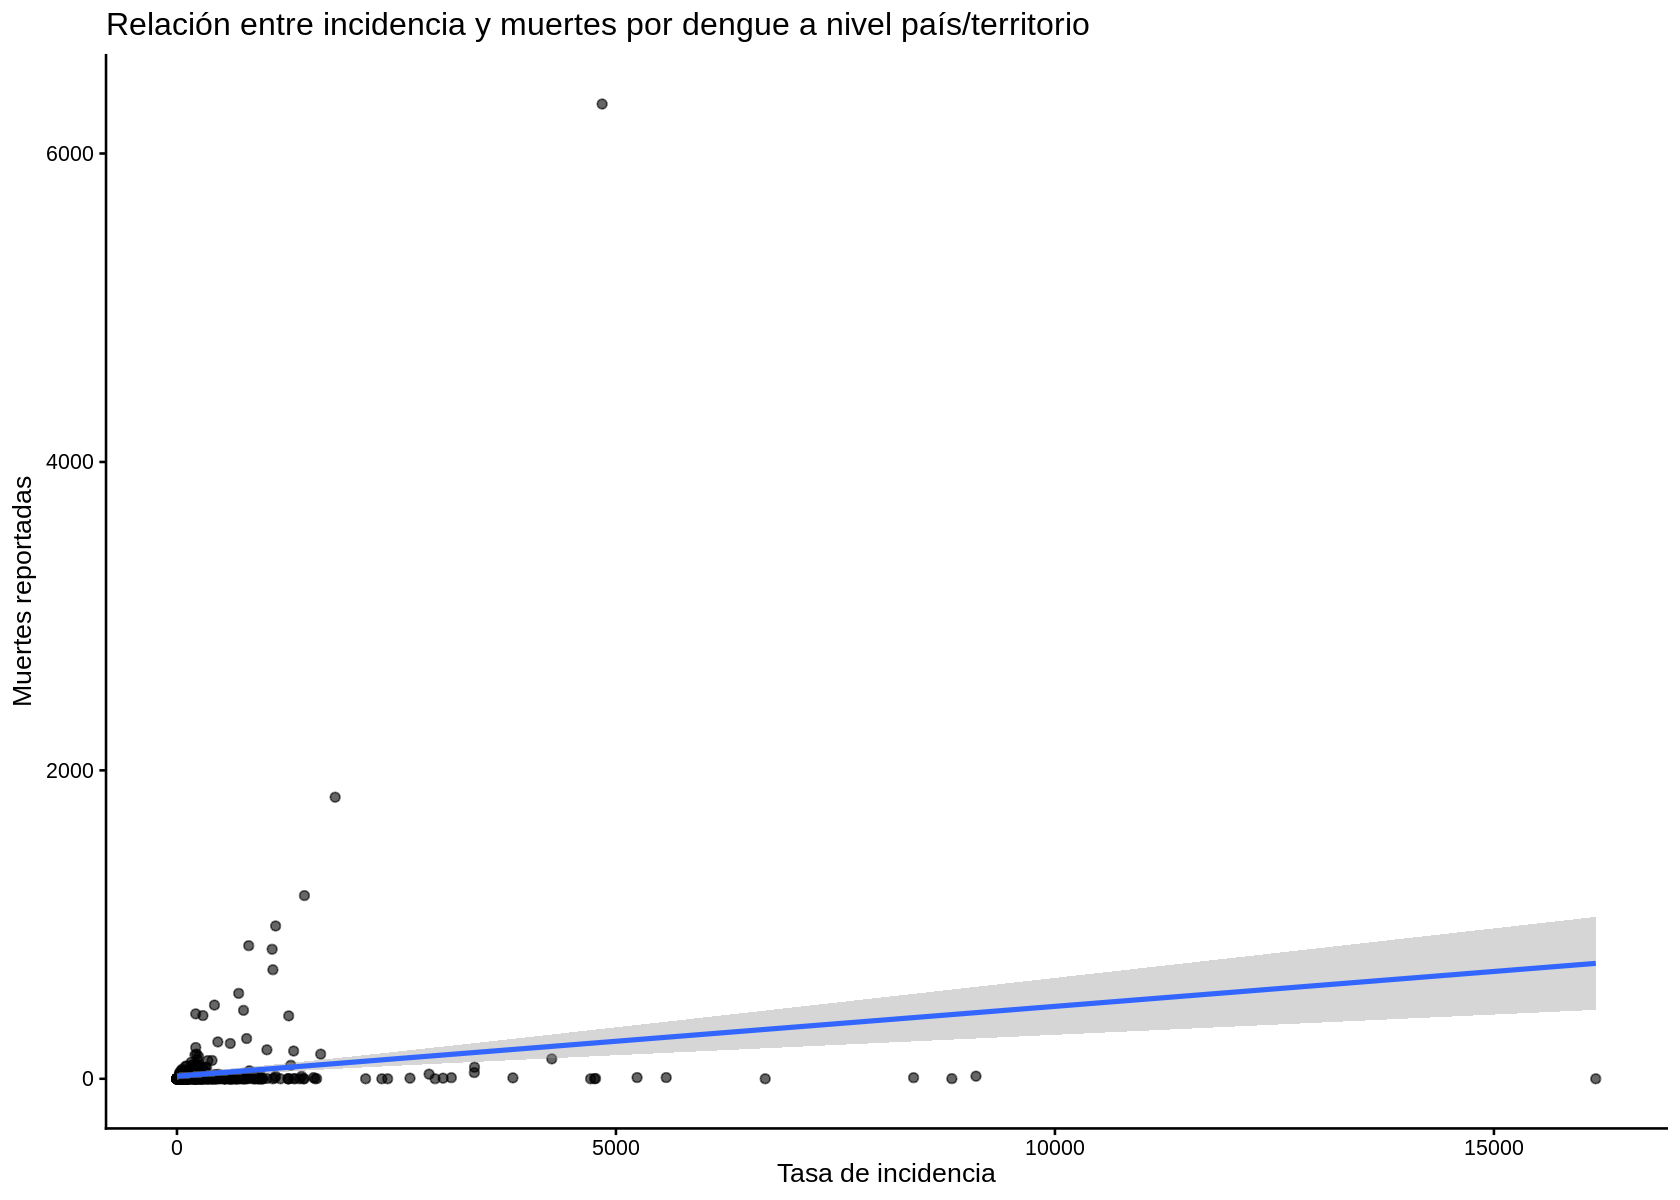

In [147]:

ggplot(dengue_paises,
       aes(x = incidence_rate_c,
           y = deaths)) +
  geom_point(alpha = 0.6) +
  geom_smooth(method = "lm", se = TRUE) +
  labs(
    title = "Relación entre incidencia y muertes por dengue a nivel país/territorio",
    x = "Tasa de incidencia",
    y = "Muertes reportadas"
  ) +
  theme_classic(base_size = 16)

In [148]:
modelo_paises <- lm(
  deaths ~ incidence_rate_c,
  data = dengue_paises
)

summary(modelo_paises)


Call:
lm(formula = deaths ~ incidence_rate_c, data = dengue_paises)

Residuals:
   Min     1Q Median     3Q    Max 
-748.5  -24.6  -17.8  -17.0 6084.8 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)      17.042999  11.564756   1.474    0.141    
incidence_rate_c  0.045261   0.009705   4.664  3.8e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 274.4 on 626 degrees of freedom
Multiple R-squared:  0.03358,	Adjusted R-squared:  0.03203 
F-statistic: 21.75 on 1 and 626 DF,  p-value: 3.8e-06



	Shapiro-Wilk normality test

data:  residuals(modelo_paises)
W = 0.14214, p-value < 2.2e-16



	studentized Breusch-Pagan test

data:  modelo_paises
BP = 20.149, df = 1, p-value = 7.162e-06


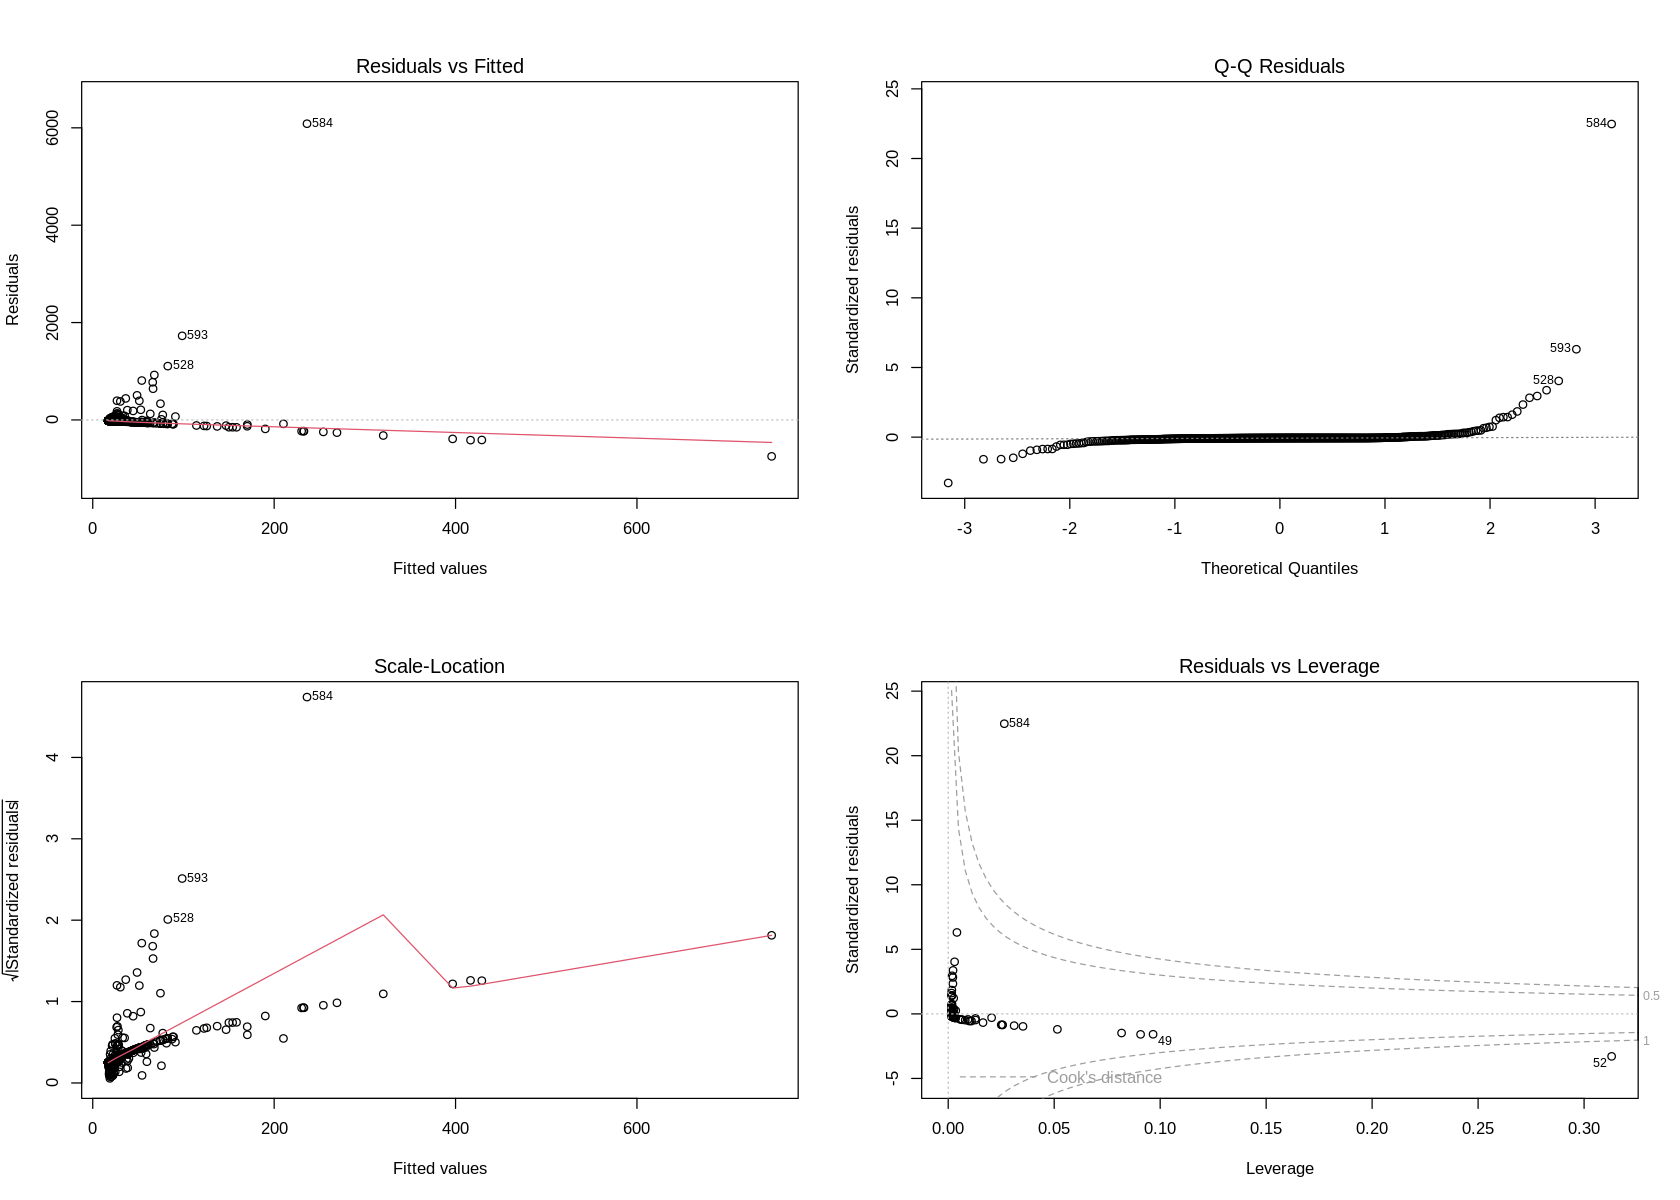

,StudRes,Hat,CookD
,<dbl>,<dbl>,<dbl>
49,-1.581587,0.096660990,0.13351079
52,-3.317372,0.312999388,2.46750802
584,51.121948,0.026466774,6.86707332
593,6.514217,0.004108265,0.08209302


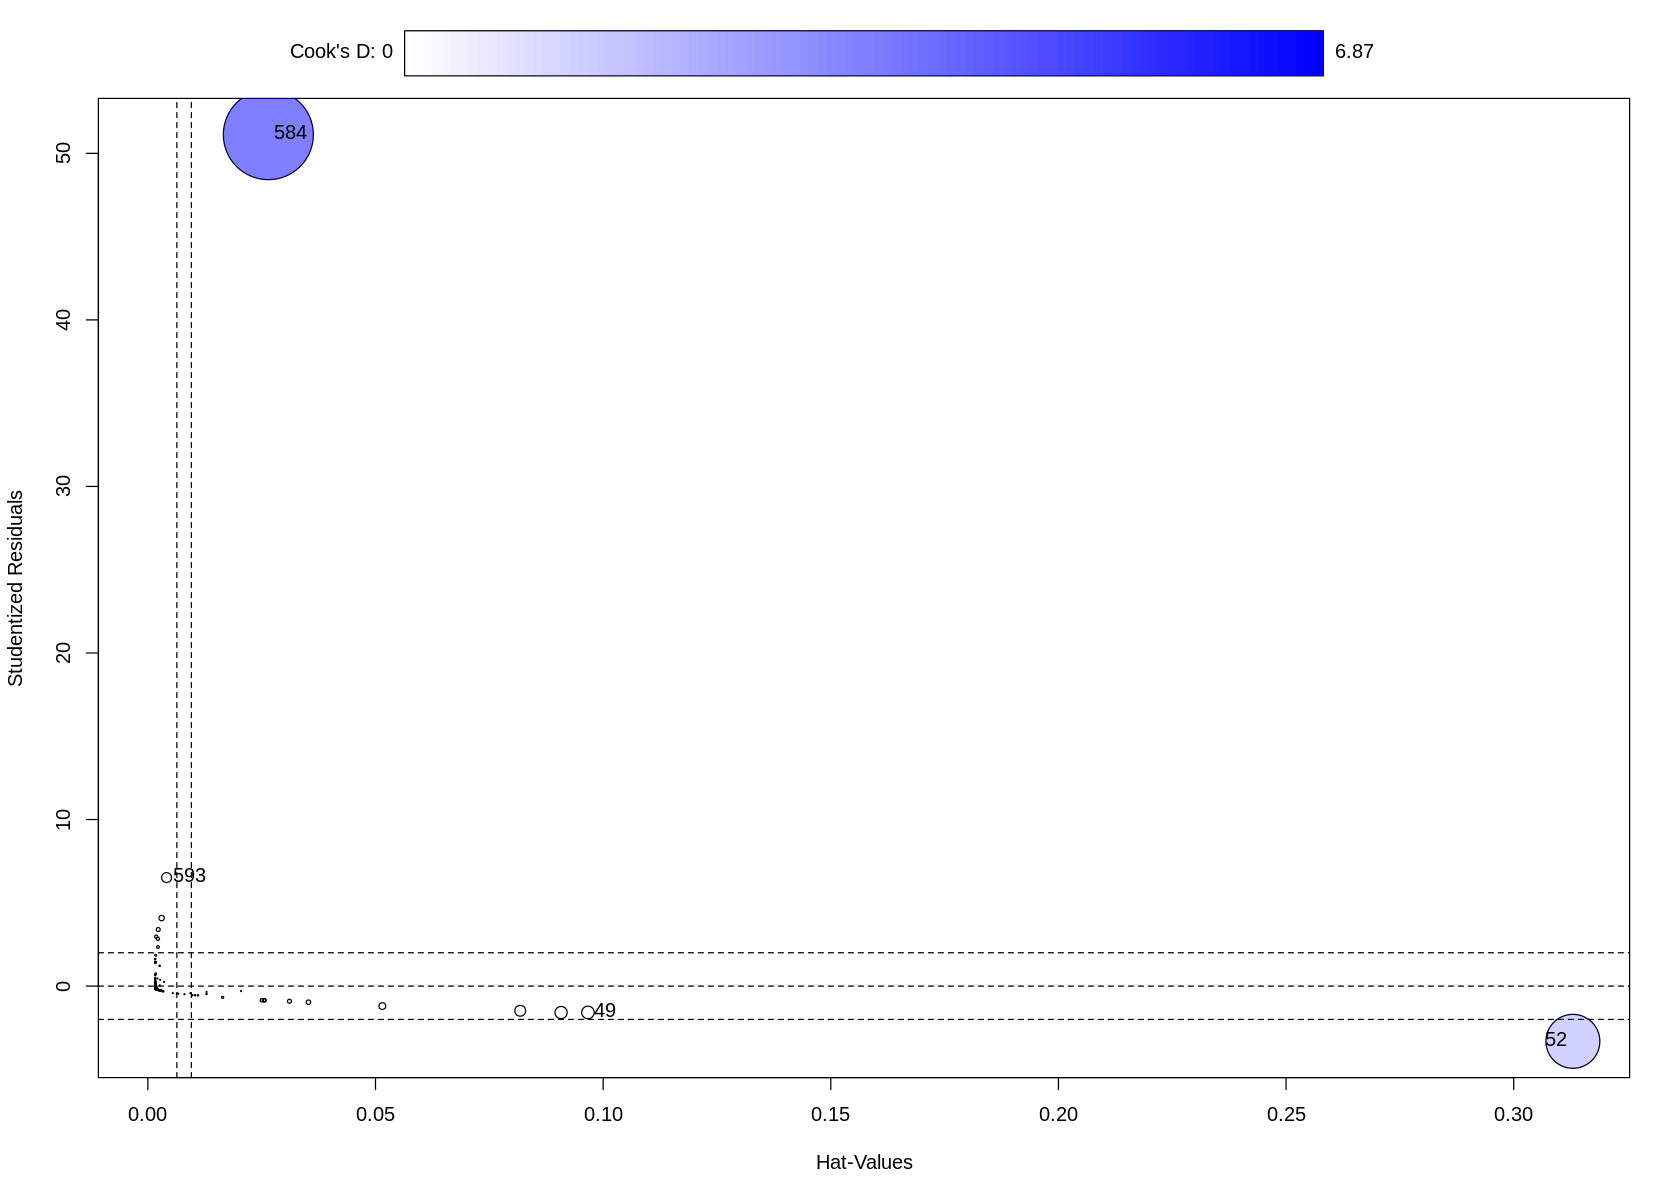

In [149]:
par(mfrow = c(2,2))
plot(modelo_paises)
par(mfrow = c(1,1))

shapiro.test(residuals(modelo_paises))

library(lmtest)
bptest(modelo_paises)

library(car)
influencePlot(modelo_paises)


Call:
lm(formula = log1p(deaths) ~ log1p(incidence_rate_c), data = dengue_paises)

Residuals:
    Min      1Q  Median      3Q     Max 
-2.5677 -1.0883 -0.2794  0.2034  6.5241 

Coefficients:
                        Estimate Std. Error t value Pr(>|t|)    
(Intercept)             -0.16660    0.11941  -1.395    0.163    
log1p(incidence_rate_c)  0.28217    0.02605  10.833   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.518 on 626 degrees of freedom
Multiple R-squared:  0.1579,	Adjusted R-squared:  0.1565 
F-statistic: 117.4 on 1 and 626 DF,  p-value: < 2.2e-16



	Shapiro-Wilk normality test

data:  residuals(modelo_paises_log)
W = 0.8846, p-value < 2.2e-16



	studentized Breusch-Pagan test

data:  modelo_paises_log
BP = 108.61, df = 1, p-value < 2.2e-16


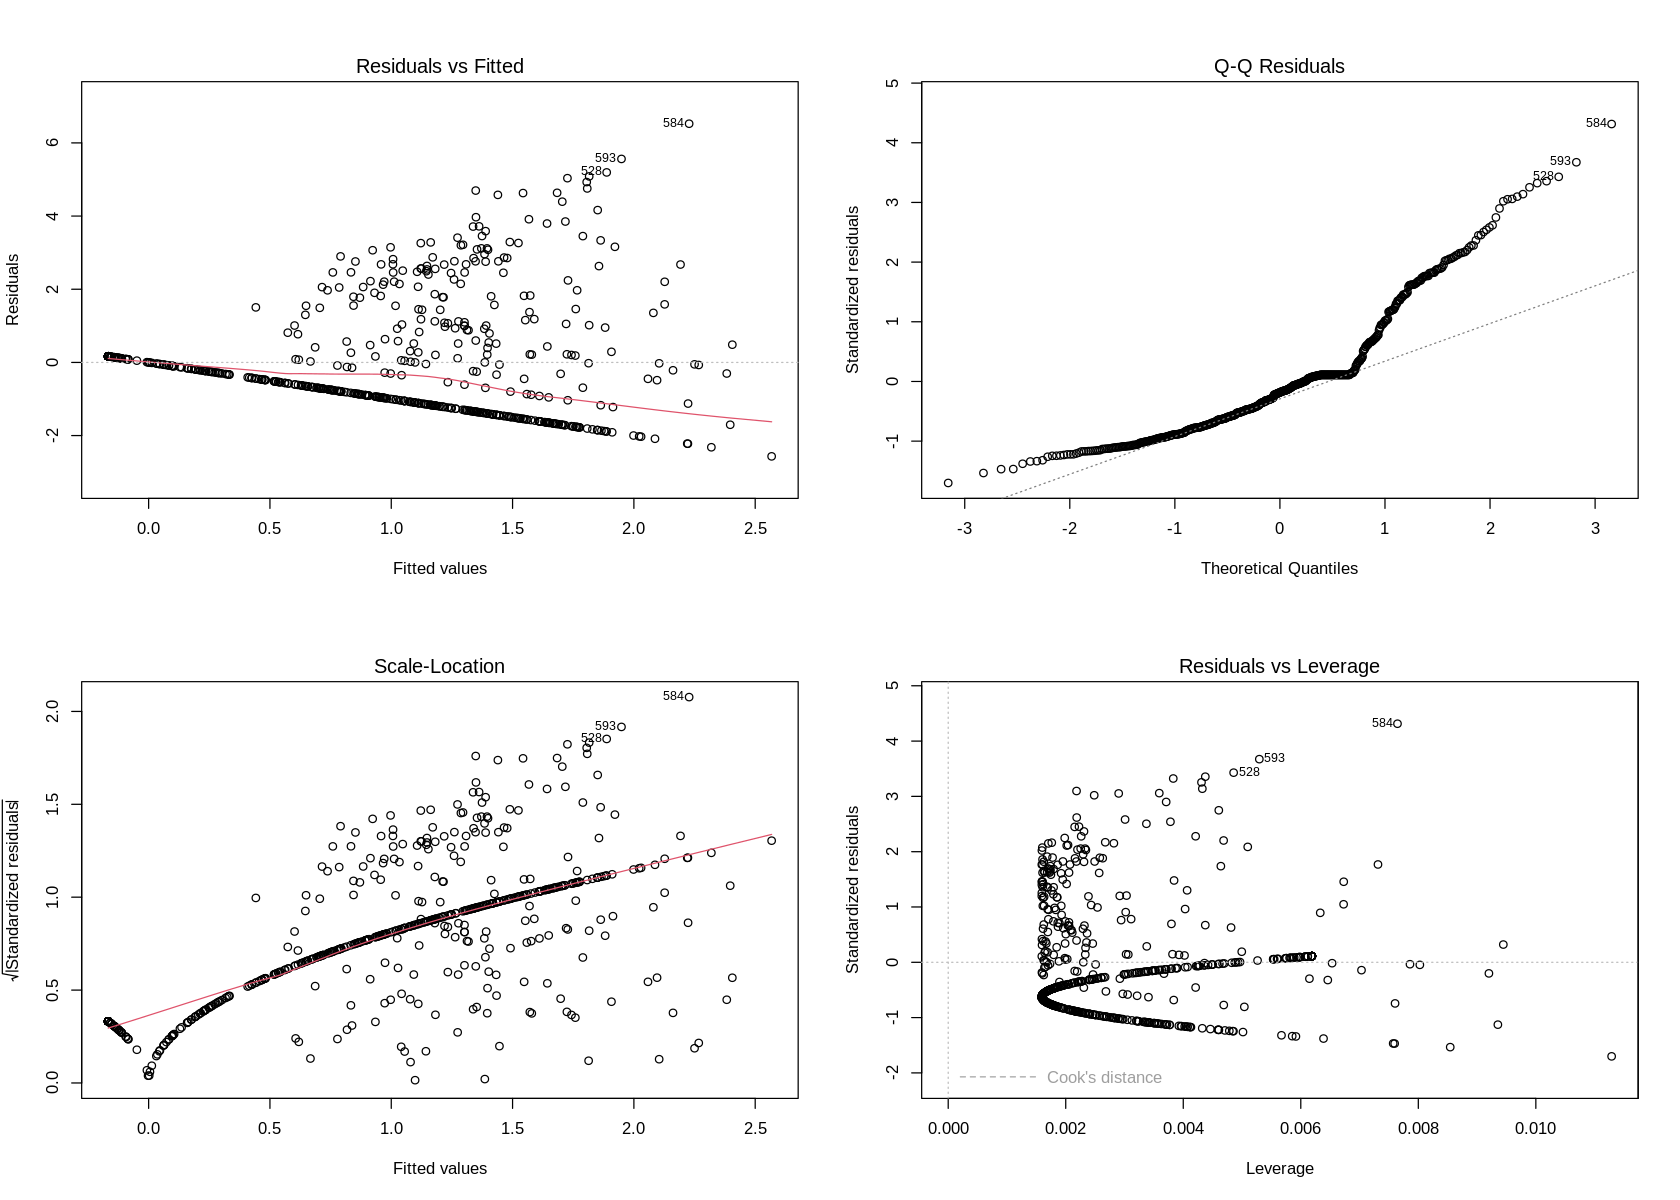

In [150]:
modelo_paises_log <- lm(
  log1p(deaths) ~ log1p(incidence_rate_c),
  data = dengue_paises
)

summary(modelo_paises_log)

par(mfrow = c(2,2))
plot(modelo_paises_log)
par(mfrow = c(1,1))

shapiro.test(residuals(modelo_paises_log))

bptest(modelo_paises_log)

In [151]:
cor.test(
  dengue_paises$incidence_rate_c,
  dengue_paises$deaths,
  method = "pearson"
)

cor.test(
  dengue_paises$incidence_rate_c,
  dengue_paises$deaths,
  method = "spearman"
)


	Pearson's product-moment correlation

data:  dengue_paises$incidence_rate_c and dengue_paises$deaths
t = 4.6636, df = 626, p-value = 3.8e-06
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.1065295 0.2577832
sample estimates:
      cor 
0.1832406 


Warning message in cor.test.default(dengue_paises$incidence_rate_c, dengue_paises$deaths, :
“cannot compute exact p-value with ties”



	Spearman's rank correlation rho

data:  dengue_paises$incidence_rate_c and dengue_paises$deaths
S = 24329240, p-value < 2.2e-16
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.4106111 


Al restringir el análisis a países y territorios, se observó una asociación positiva entre la tasa de incidencia y las muertes reportadas. Sin embargo, la regresión lineal simple presentó baja capacidad explicativa, con un R² cercano al 3,4%, además de incumplimiento de los supuestos de normalidad y homocedasticidad. La transformación logarítmica de ambas variables mejoró el ajuste del modelo, aumentando el R² a aproximadamente 15,8%, aunque persistieron problemas en los residuos. Estos resultados sugieren que la incidencia se asocia con la mortalidad, pero no la explica completamente, por lo que probablemente intervienen otros factores epidemiológicos, sanitarios y poblacionales.

En consecuencia, la tasa de incidencia por sí sola no permite explicar adecuadamente las muertes reportadas por dengue, especialmente a nivel país, donde existen diferencias importantes en tamaño poblacional, capacidad diagnóstica, vigilancia epidemiológica y respuesta sanitaria.